## PSILO

In [32]:
#Libraries 
import os
import time
import math
import numpy as np
import pandas as pd
import scipy
import scipy.signal as spsg
from scipy import stats,linalg
from scipy.io import loadmat
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.cluster import KMeans
from scipy.spatial.distance import cityblock
from data.labels_brain import reorder_matrix
from tqdm import tqdm
from scipy.stats import pearsonr, mannwhitneyu
from data.diagram_plots import Region_Heatmap,chord_diagram
from matplotlib.gridspec import GridSpec



#random.seed(42)

### Reading Data

In [2]:
# Read the data
data_path= "C:/Users/diego/Desktop/phase_coherance_consciousness/data"

#Some of the data is corrupted, we chose manually the patiens we want to read.
num_patients=[0,1,2,3,4,6,7,8,9,10,12,13,14]
num=len(num_patients)

data_PSILO = os.path.join(data_path, "PSILO_TS_FC.mat")
data_PSILO = loadmat(data_PSILO)
data_PSILO = data_PSILO["DataCorrel"].flatten()

#Some of the data is corrupted, we chose manually the patiens we want to read.
#num_patients=range(data_PSILO["TS_Psilo"].shape[0])
num_patients=[0,1,2,3,4,6,7,8,9,10,12,13,14]
num=len(num_patients)

PSILOACAT = np.hstack([data_PSILO["TS_Psilo"][i] for i in num_patients])
PSILOPCAT = np.hstack([data_PSILO["TS_PCB"][i] for i in num_patients])

PSILO_Signals = np.hstack((PSILOACAT, PSILOPCAT))
print(f"PSILO concatenated signals: {PSILO_Signals.shape} from {data_PSILO.shape[0]} patients.")

PSILO concatenated signals: (90, 2487) from 15 patients.


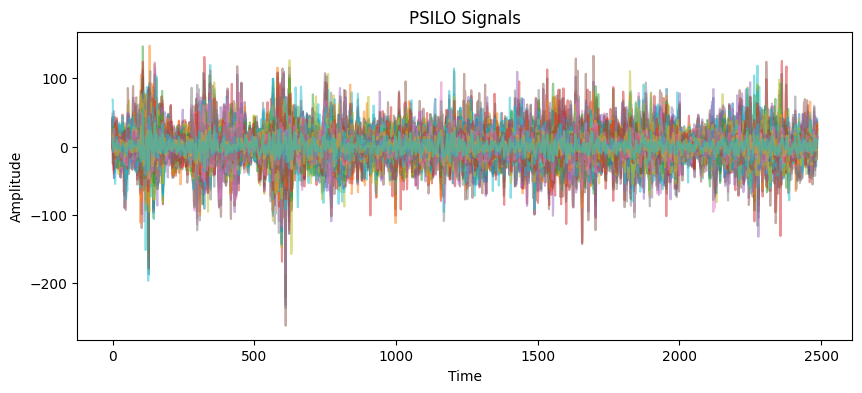

In [3]:
# Initial visualization of the Bold Signals (Time Series)
plt.figure(figsize=(10, 4))
plt.plot(PSILO_Signals.T, alpha=0.5)
plt.title("PSILO Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Extract Size and Features

In [4]:
#Number of Regions and Total Time
ROI,time_length = PSILO_Signals.shape

# Loop over each region to extract the lenght of each signal.
Time_per_subj = np.zeros(ROI, dtype=int)
for i in range(ROI):
    Time_per_subj[i] = len(PSILO_Signals[i])


print(f" Number of Regions (ROI): {ROI} \n Total Time: {time_length}")

 Number of Regions (ROI): 90 
 Total Time: 2487


### Import the Connectoma 

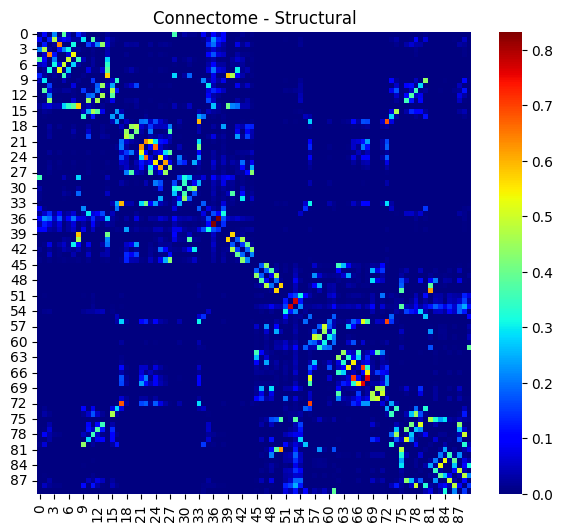

In [5]:
# Import the atlas
data_connectome = os.path.join(data_path, "./structural.mat")
CC = loadmat(data_connectome)['A']

# Plot it
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(CC, cmap='jet',cbar=True, ax=ax)
ax.set_title(f"Connectome - Structural")
plt.show()

In [6]:
np.info(CC)

class:  ndarray
shape:  (90, 90)
strides:  (8, 720)
itemsize:  8
aligned:  True
contiguous:  False
fortran:  True
data pointer: 0x213e9c92b10
byteorder:  little
byteswap:  False
type: float64


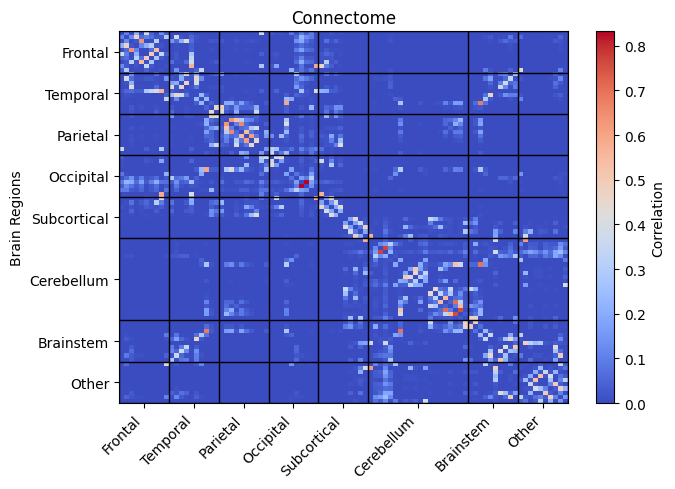

In [7]:
#Example of Usage (Region-Heatmap)
fig = Region_Heatmap(CC, 
                     region_boundaries=[10,20,30,40,50,70,80,90],
                     region_names = ["Frontal", "Temporal", "Parietal", "Occipital", "Subcortical", "Cerebellum", "Brainstem", "Other"],
                     name="Connectome",
                     scaling=True)
plt.show()

### Preprocess Functions 

In [8]:
# Function to apply a Butterworth bandpass filter to a time series.
# It is particularly useful for removing noise and smoothing the signal in the specified frequency range.
def butterworth_filtering(ts):
    """
    Apply a Butterworth bandpass filter to the input time series `ts`.

    Parameters:
    ts : array-like
        The input time series (1D or 2D array).
        
    Returns:
    filtered_ts : array-like
        The filtered time series, same shape as input.
        
    Notes:
    - The filter settings are dependent on the experimental setup (TR = 2.4 seconds).
    - A 3rd-order Butterworth bandpass filter is applied with cutoff frequencies of 0.01 and 0.2 times the Nyquist frequency.
    - The Nyquist frequency is determined by the repetition time (TR = 2.4s).
    """
    # Parameters
    n_order = 3  # Filter order
    TR = 2.4  # Repetition time (in seconds, relevant for fMRI experiments)
    Nyquist_freq = 0.5 / TR  # Nyquist frequency (half the sampling rate)
    low_f = 0.01 / Nyquist_freq  # Low cutoff frequency (fraction of Nyquist)
    high_f = 0.2 / Nyquist_freq  # High cutoff frequency (fraction of Nyquist)
    
    # Design the Butterworth bandpass filter
    b, a = spsg.iirfilter(n_order, (low_f, high_f), btype='bandpass', ftype='butter', output='ba')
    
    # Apply the filter to the time series using zero-phase filtering
    filtered_ts = spsg.filtfilt(b, a, ts, axis=-1)
    
    return filtered_ts

In [9]:
def adif(a, b):
    """
    Calculate the angular difference between two angles `a` and `b` in radians.

    Parameters:
    a, b : float
        The input angles in radians.
        
    Returns:
    float
        The angular difference between the two angles, always in the range [0, π]. The smallest angel diffence.
    """
    if abs(a - b) > math.pi:
        return 2 * math.pi - abs(a - b)
    else:
        return abs(a - b)


### Phase difference between each pair of regions

In [10]:
timeseriedata = np.empty((ROI, time_length))
Amplitude = np.empty((ROI, time_length))
Phases = np.empty((ROI, time_length))

# For each Region we preprocess the signal to exctract instantaneous phase
for i in range(ROI):

    #Extract the signal
    ts = PSILO_Signals[i,:]

    # Normalize the signal using Z-score
    ts_z = stats.zscore(ts)

    # Subtract the mean
    ts_z = ts_z-np.mean(ts_z,axis=0)

    # Apply the Butterworth filter 
    #ts_filtered = butterworth_filtering(ts_z)
    ts_filtered = ts_z
    
    timeseriedata[i, :] = ts_filtered

    # Perform the Hilbert transform
    hilbert_tf = spsg.hilbert(ts_z, axis=-1)
    Amplitude[i, :] = np.abs(hilbert_tf)

    # Instantaneous phase
    Phases[i, :] = np.angle(hilbert_tf)

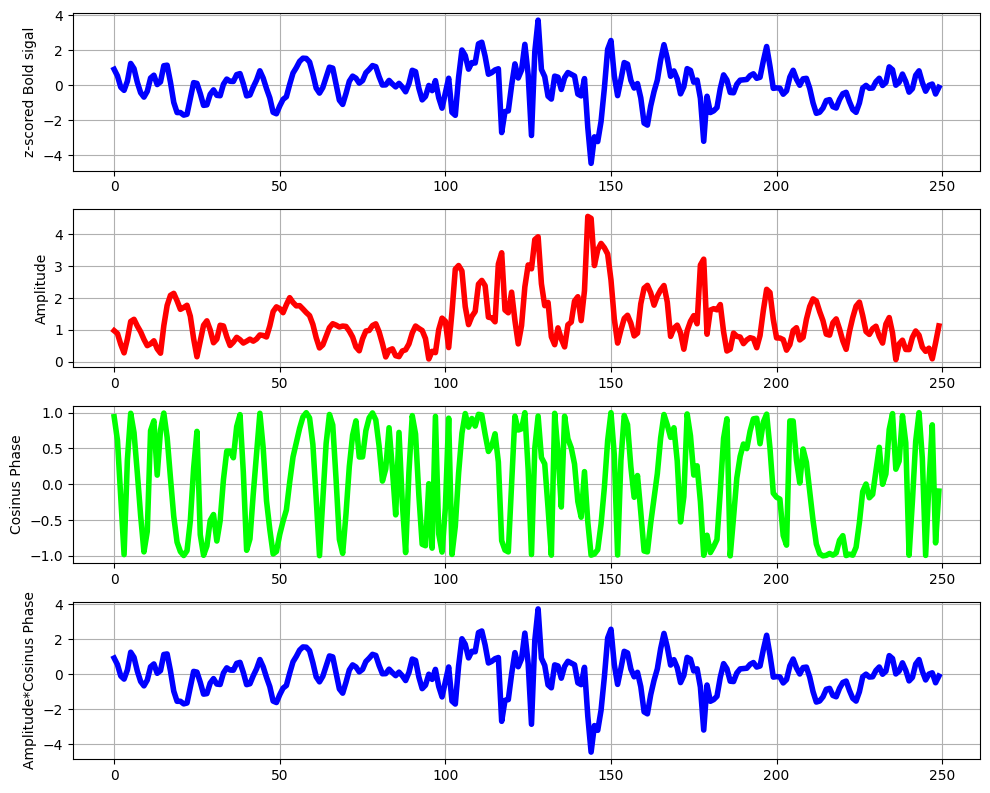

In [11]:
def createfigure(Y1, Y2, Y3, Y4):
    """
    Creates a figure with 4 vertical subplots to visualize:
    - Y1: Z-scored signal (e.g., bold)
    - Y2: Amplitude
    - Y3: Cosine of the phase
    - Y4: Amplitude * cosine of the phase
    """

    fig, axs = plt.subplots(4, 1, figsize=(10, 8))
    
    axs[0].plot(Y1, linewidth=4, color=[0, 0, 1])
    axs[0].set_ylabel('z-scored Bold sigal')
    axs[0].grid(True) 
    
    axs[1].plot(Y2, linewidth=4, color=[1, 0, 0])
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True)
    
    
    axs[2].plot(Y3, linewidth=4, color=[0, 1, 0])
    axs[2].set_ylabel('Cosinus Phase')
    axs[2].grid(True)
    
    axs[3].plot(Y4, linewidth=4, color=[0, 0, 1])
    axs[3].set_ylabel('Amplitude*Cosinus Phase')
    axs[3].grid(True)
    
    plt.tight_layout()
    plt.show()

#We replicate a signal
Y1 = timeseriedata[0, :250]
Y2 = Amplitude[0, :250]
Y3 = np.cos(Phases[0, :250])
Y4 = Amplitude[0, :250] * np.cos(Phases[0, :250])
createfigure(Y1, Y2, Y3, Y4)

### Vectorized Computation for each time instant 

In [12]:
# Number of pairs (only the lower part of the matrix): ROI*(ROI-1)/2
row_idx, col_idx = np.tril_indices(ROI, k=-1)
sorted_indices = np.lexsort((row_idx, col_idx))
lower_indices_corrected = (row_idx[sorted_indices], col_idx[sorted_indices])


num_pairs = len(lower_indices_corrected[0])
pattern = np.empty((num_pairs, time_length))


# Vectorized computation for each time instant
for t in range(time_length):
    patt = np.empty((ROI, ROI))
    for i in range(ROI):
        for j in range(i):
            patt[i,j] = np.cos(adif(Phases[i,t],Phases[j,t]))
    pattern[:, t] = patt[lower_indices_corrected]
    

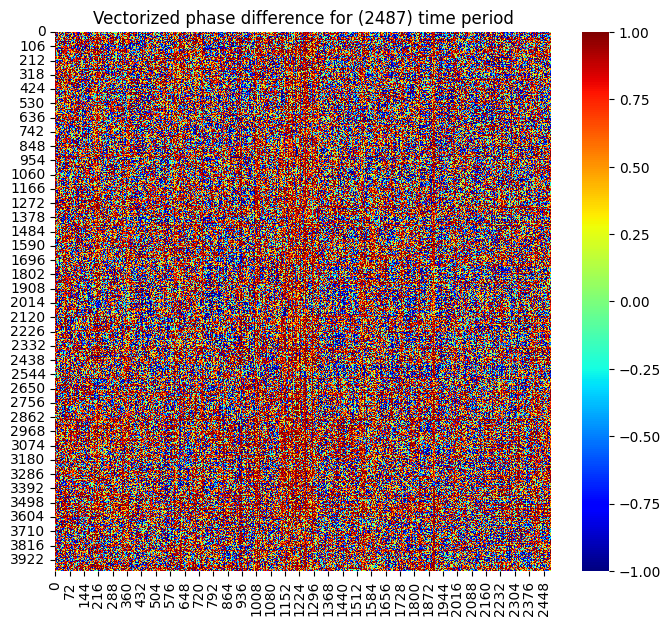

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pattern, cmap='jet', vmin=-1, vmax=1, cbar=True, ax=ax)
ax.set_title(f"Vectorized phase difference for ({time_length}) time period")
plt.show()

### Remove Empty Images

In [14]:
all_pattern2D = pattern.T


# Empty Images
print("Size before removing empty images:", all_pattern2D.shape)
good_pattern = np.sum(np.abs(all_pattern2D), axis=1) > 0
all_pattern2D = all_pattern2D[good_pattern, :]  
print("Size after removing empty images:", all_pattern2D.shape)

# Outliers
# D = squareform(pdist(all_pattern2D, metric='cityblock'))  
# D = zscore(np.mean(D, axis=1))  
# good_pattern = D < 3 
# all_pattern2D = all_pattern2D[good_pattern, :]  
print("Size after removing outliers:", all_pattern2D.shape)


Size before removing empty images: (2487, 4005)
Size after removing empty images: (2487, 4005)
Size after removing outliers: (2487, 4005)


### Convergence Analysis

Running clustering experiments...


Experiments: 100%|██████████| 5/5 [00:54<00:00, 10.88s/it]


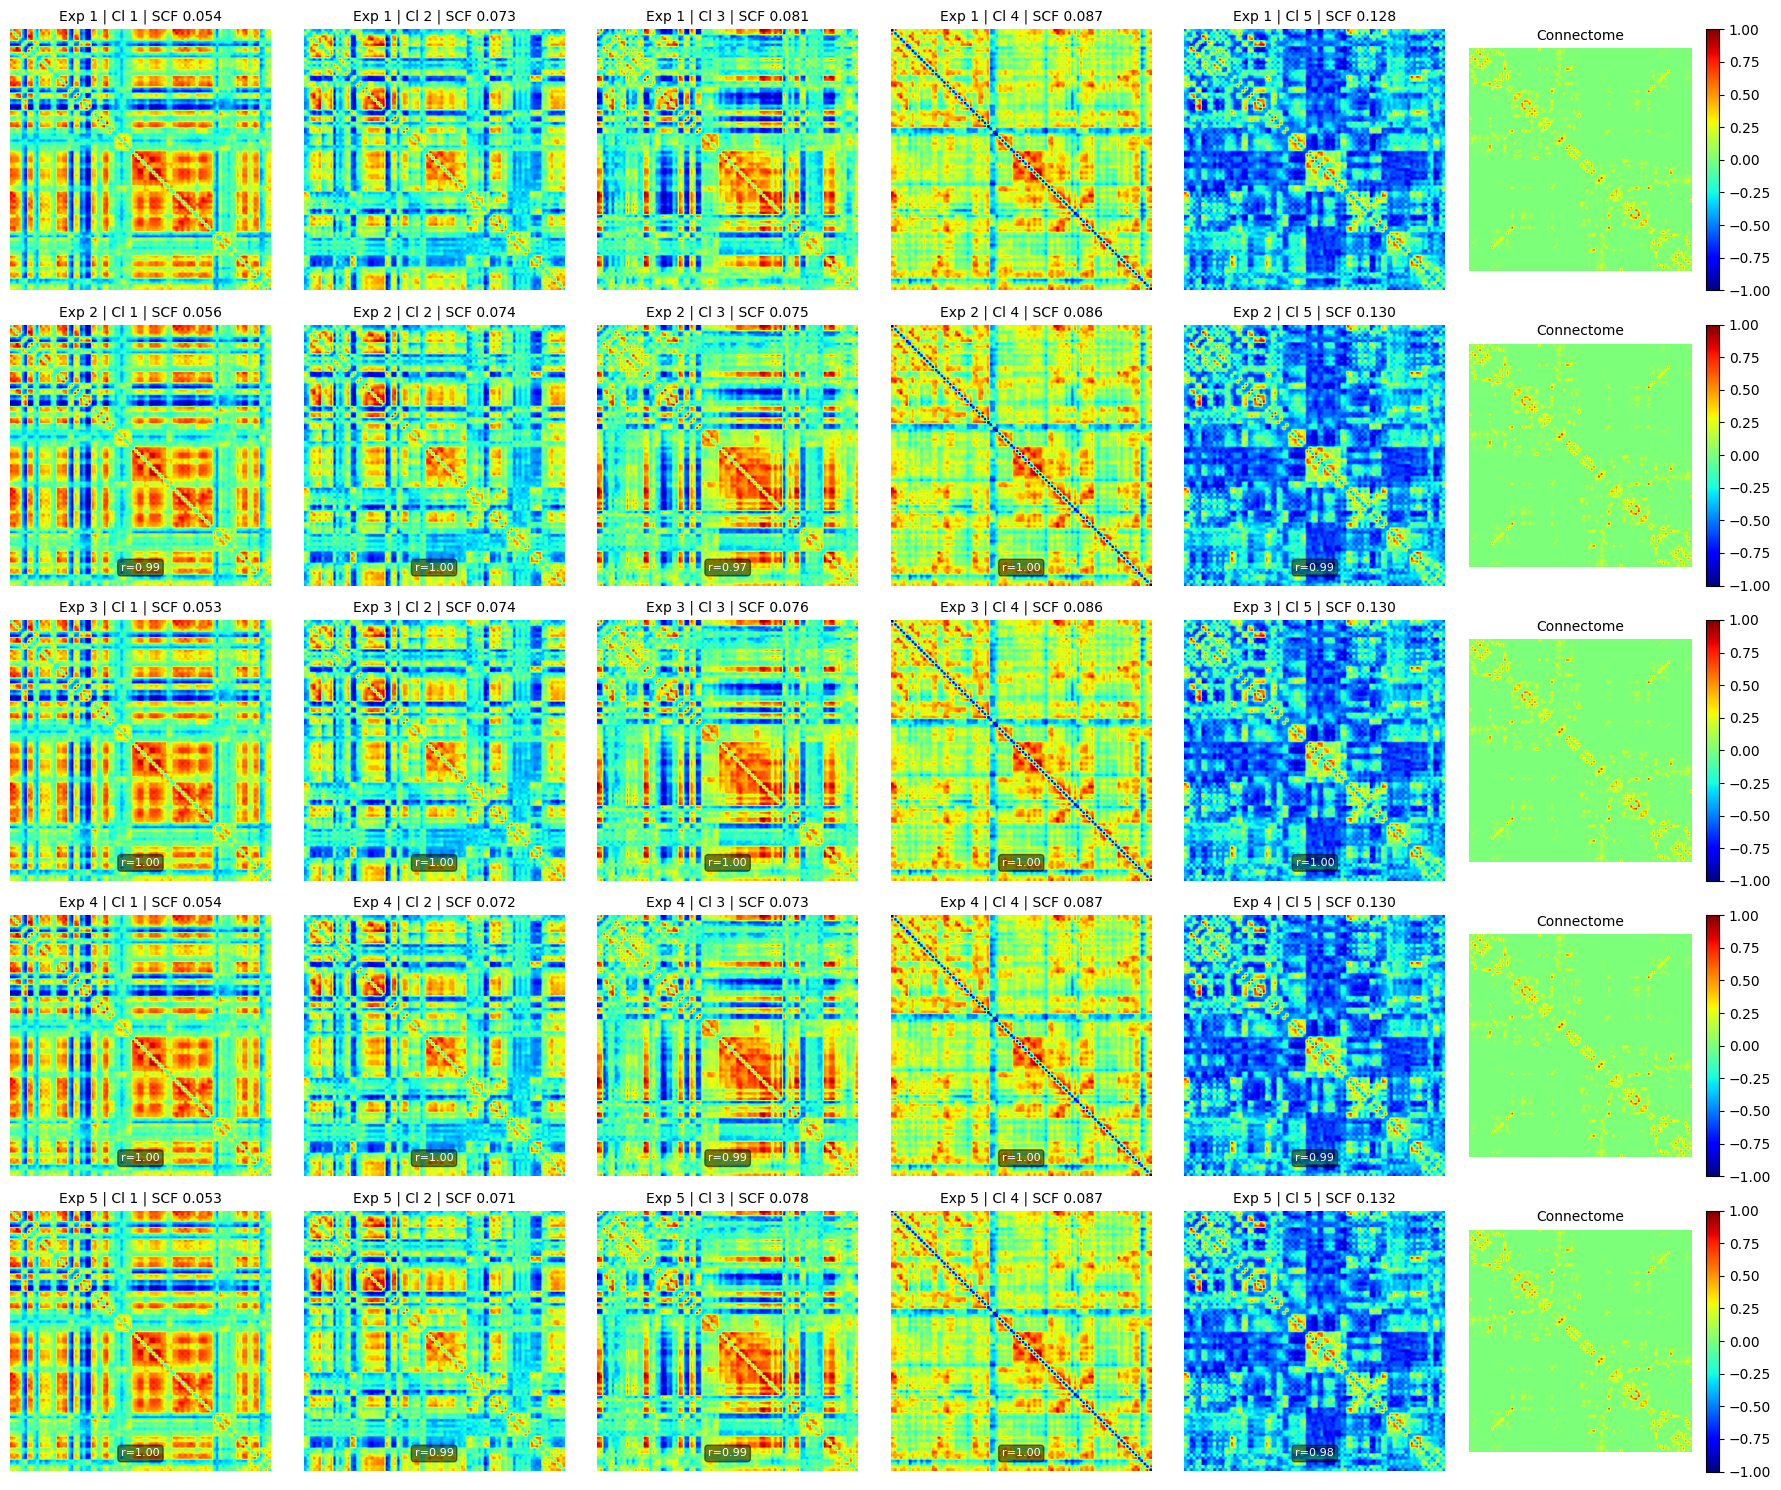

In [15]:
# ------------------------------
# Parameters for Experiments
# ------------------------------
n_clusters = 5        
max_iter = 40  
n_init = 20     
n_experiments = 5

# ------------------------------
# Run the Experiments
# ------------------------------
experiments_results = []
print("Running clustering experiments...")
for exp in tqdm(range(n_experiments), desc="Experiments"):
    kmeans = KMeans(n_clusters=n_clusters, max_iter=max_iter, n_init=n_init, random_state=None)
    kmeans.fit(all_pattern2D)
    experiments_results.append({
        'ctrs_Pha': kmeans.cluster_centers_, 
        'cidx_Pha': kmeans.labels_
    })

# ------------------------------
# Create a n_experiments x (n_clusters + connectome) Grid Plot
# ------------------------------
#fig, axs = plt.subplots(n_experiments, n_clusters, figsize=(n_clusters*3, n_experiments*3))
fig, axs = plt.subplots(n_experiments, n_clusters + 1, figsize=((n_clusters+1)*3, n_experiments*3))

# Flatten the connectome matrix
VC = CC.flatten().astype(np.float64)
sorted_indices = []

for exp in range(n_experiments):
    result = experiments_results[exp]

    CCA = np.zeros(n_clusters)
    for i in range(n_clusters):
        centroid_vector = result['ctrs_Pha'][i, :]
        QQ = squareform(centroid_vector) 
        VA = QQ.flatten()
        MC = np.corrcoef(VA, VC)  # Correlation with the connectome
        CCA[i] = MC[0, 1]

    B = np.sort(CCA)
    I = np.argsort(CCA)
    sorted_indices.append(I)
    
    for cl in range(n_clusters):
        QQ = squareform(result['ctrs_Pha'][I[cl], :])
        im = axs[exp, cl].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
        axs[exp, cl].set_title(f"Exp {exp+1} | Cl {cl+1} | SCF {B[cl]:.3f}", fontsize=10)
        axs[exp, cl].axis('off')
        
        # Correlation between experiments
        if exp > 0:
            prev_centroid = experiments_results[exp-1]['ctrs_Pha'][sorted_indices[exp-1][cl], :]
            current_centroid = result['ctrs_Pha'][I[cl], :]
            corr, _ = pearsonr(prev_centroid, current_centroid)
            axs[exp, cl].text(0.5, 0.05, f"r={corr:.2f}", color='white', fontsize=8,
                              ha='center', va='bottom', transform=axs[exp, cl].transAxes,
                              bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    
    # Connectome matrix 
    connectome_im = axs[exp, n_clusters].imshow(CC, vmin=-1, vmax=1, cmap='jet')
    axs[exp, n_clusters].set_title("Connectome", fontsize=10)
    axs[exp, n_clusters].axis("off")
    plt.colorbar(connectome_im, ax=axs[exp, n_clusters])

plt.tight_layout()
plt.show()

### K-Means

In [16]:
# Parameters
Kmeans_results = {} 

# Manhattan distance
def compute_manhattan_distance(data_point, centroids, cluster_labels):
    return cityblock(data_point, centroids[cluster_labels])

# KMeans clustering for each k (currently just k=5)
for k in [5]:
    kmeans = KMeans(n_clusters=k, max_iter=40, n_init=20, random_state=None)
    kmeans.fit(all_pattern2D)

    cidx_Pha = kmeans.labels_
    ctrs_Pha = kmeans.cluster_centers_

    #Manhattan distances
    sum_D_Pha = np.sum([compute_manhattan_distance(all_pattern2D[i], ctrs_Pha, cidx_Pha[i]) for i in range(all_pattern2D.shape[0])])

    Kmeans_results[k] = {
        "cidx_Pha": cidx_Pha,
        "ctrs_Pha": ctrs_Pha,
        "sum_D_Pha": sum_D_Pha
    }

# Verify Dimensions
print(f"cidx_Pha shape: {Kmeans_results[5]['cidx_Pha'].shape}")
print(f"ctrs_Pha shape: {Kmeans_results[5]['ctrs_Pha'].shape}")
print(f"sum_D_Pha: {Kmeans_results[5]['sum_D_Pha']}")


cidx_Pha shape: (2487,)
ctrs_Pha shape: (5, 4005)
sum_D_Pha: 5666469.259187773


### Centroid Probability Calculation Function and Consecutive Run Length

- Centroid Probability Calculation: 

The probability of a given centroid $c$ occurring for a subject $s$ is given by:

$$
\Pi^{(s,c)}_\alpha = \frac{1}{T} \sum_{t=1}^{T} \mathbf{1} \left\{ X_t \in P_c \right\}
$$

Where:
- $\Pi^{(s,c)}_\alpha$ represents the probability of centroid $c$ occurring for subject $s$ in state $\alpha$ (either placebo or drug)
- $T$ is the total number of time points for that subject in that state
- $\mathbf{1}\{\cdot\}$ is the indicator function that equals 1 when the condition is met and 0 otherwise
- $X_t$ is the centroid assignment at time point $t$
- $P_c$ represents the set of points belonging to centroid $c$

- Consecutive Run Length

For a sequence of centroids $X = [X_1, X_2, \ldots, X_T]$ where each $X_t \in \{0,1,\ldots,k\}$, we define a consecutive run of centroid $c$ as a maximal subsequence where all elements equal $c$.

In [17]:
#First we extract the index per each Subject and state (Drug or Placebo)
plc_shapes = np.array([data_PSILO["TS_Psilo"][i].shape[1] for i in num_patients])
drug_shape = np.array([data_PSILO["TS_PCB"][i].shape[1] for i in num_patients])


plc_idx = np.cumsum(plc_shapes)-1
drug_idx = plc_idx[-1] + np.cumsum(drug_shape)

#Centroids
Centroids = Kmeans_results[5]['cidx_Pha']

In [18]:
# Initialize
rows = []
k = max(Centroids)
start_idx = 0

# Combine both state indices and state names
all_indices = [(idx, 'Placebo') for idx in plc_idx] + [(idx, 'Drug') for idx in drug_idx]
subject_counter = 0

# Calculate the prob for all subjects and states (Placebo and Drug)
for i, (end_idx, state) in enumerate(all_indices):

    if i == len(plc_idx):
        subject_counter = 0
    
    #Exctract the centroids per subject
    subject_centroids = Centroids[start_idx:end_idx]
    
    # Calculate probability 
    unique_centroids, counts = np.unique(subject_centroids, return_counts=True)
    centroid_counts = dict(zip(unique_centroids, counts))
    total_observations = len(subject_centroids)
    
    
    avg_consecutive = {}
    median_consecutive = {}
   
    for centroid in range(k + 1):

        # Calculate average consecutive length - median for each centroid
        runs = []
        current_run = 0
        
        for c in subject_centroids:
            if c == centroid:
                current_run += 1
            elif current_run > 0:
                runs.append(current_run)
                current_run = 0
                
    
        if current_run > 0:
            runs.append(current_run)
            
        # Calculate average - median
        if runs:
            avg_consecutive[centroid] = sum(runs) / len(runs)
            median_consecutive[centroid] = np.median(runs)
        else:
            avg_consecutive[centroid] = 0
            median_consecutive[centroid] = 0


        frequency = centroid_counts.get(centroid, 0)
        probability = frequency / total_observations
        avg_consec = avg_consecutive.get(centroid, 0)
        median_consec = median_consecutive.get(centroid,0)

        rows.append({
            'Subject': num_patients[subject_counter]+1,
            'State': state,
            'Centroid': centroid,
            'Frequency': frequency,
            'Probability': probability,
            'Avg_Consecutive': avg_consec,
            'Median_Consecutive': median_consec
        })
    
    subject_counter = (subject_counter + 1) if i != len(plc_idx) - 1 else subject_counter
    start_idx = end_idx

# Dataframe
result_df = pd.DataFrame(rows)
result_df['Probability'] = result_df['Probability'].round(4)
result_df['Avg_Consecutive'] = result_df['Avg_Consecutive'].round(2)
result_df['Centroid'] = result_df['Centroid'] + 1
result_df = result_df.sort_values(by=['Subject', 'State', 'Centroid']).reset_index(drop=True)

In [19]:
#Per subject
result_df.head(20)

,Subject,State,Centroid,Frequency,Probability,Avg_Consecutive,Median_Consecutive
0,1,Drug,1,51,0.5258,4.25,3.5
1,1,Drug,2,14,0.1443,3.50,3.5
2,1,Drug,3,16,0.1649,2.00,1.5
3,1,Drug,4,7,0.0722,1.75,1.0
4,1,Drug,5,9,0.0928,1.29,1.0
5,1,Placebo,1,21,0.2188,5.25,4.0
6,1,Placebo,2,18,0.1875,4.50,4.5
7,1,Placebo,3,32,0.3333,3.56,2.0
8,1,Placebo,4,20,0.2083,2.86,2.0
9,1,Placebo,5,5,0.0521,1.67,1.0


#### Analyzing State Transitions in Subject Data: Removing Consecutive Repetitions

This code analyzes transition patterns between different states (centroids) in subject data while filtering out consecutive repetitions. By removing consecutive duplicate states, we focus on actual state changes rather than persistence within states. 

This approach allows us to quantify how frequently subjects transition between specific states, providing insight into pattern changes while eliminating the effect of varying durations spent in each state.

#### Transition Count Matrix

The transition count matrix $C$, where each element $C_{ij}$ represents the count of transitions from centroid $i$ to centroid $j$:

$$
C_{ij} = \sum_{t=1}^{T-1} \mathbf{1} \{X_t = i \text{ and } X_{t+1} = j\}
$$

In [20]:
# Function to remove consecutive duplicates
def remove_consecutive_duplicates(arr):
    if len(arr) == 0:
        return arr
    result = [arr[0]]
    for i in range(1, len(arr)):
        if arr[i] != arr[i-1]:
            result.append(arr[i])
    return result

# Initialize
transition_rows = []
k = max(Centroids)
start_idx = 0

# Combine both state indices and state names
all_indices = [(idx, 'Placebo') for idx in plc_idx] + [(idx, 'Drug') for idx in drug_idx]
subject_counter = 0

# Process each subject
for i, (end_idx, state) in enumerate(all_indices):
    if i == len(plc_idx):
        subject_counter = 0
    
    # Extract the centroids per subject
    subject_centroids = Centroids[start_idx:end_idx]
    
    # Remove consecutive duplicates
    subject_centroids_no_rep = remove_consecutive_duplicates(subject_centroids)
    
    # Transition Dictionary
    transitions = {}
    for from_state in range(k + 1):
        for to_state in range(k + 1):
            if from_state != to_state: 
                transitions[f"{from_state+1} to {to_state+1}"] = 0
    
    # Count transitions
    for j in range(len(subject_centroids_no_rep) - 1):
        from_state = subject_centroids_no_rep[j]
        to_state = subject_centroids_no_rep[j + 1]
        transition_key = f"{from_state+1} to {to_state+1}"  # +1 to match your centroid numbering
        transitions[transition_key] = transitions.get(transition_key, 0) + 1
    
    
    transitions['Subject'] = num_patients[subject_counter]+1
    transitions['State'] = state
    transition_rows.append(transitions)
    subject_counter = (subject_counter + 1) if i != len(plc_idx) - 1 else subject_counter
    start_idx = end_idx

#Data Frame
transition_df = pd.DataFrame(transition_rows)
transition_df = transition_df.fillna(0)
meta_cols = ['Subject', 'State']
transition_cols = [col for col in transition_df.columns if ' to ' in col]
sorted_cols = meta_cols + sorted(transition_cols)
transition_df = transition_df[sorted_cols]
transition_df = transition_df.sort_values(by=['Subject', 'State']).reset_index(drop=True)


transition_df.head()

,Subject,State,1 to 2,1 to 3,1 to 4,1 to 5,2 to 1,2 to 3,2 to 4,2 to 5,...,3 to 4,3 to 5,4 to 1,4 to 2,4 to 3,4 to 5,5 to 1,5 to 2,5 to 3,5 to 4
0,1,Drug,3,4,3,1,1,1,0,2,...,1,4,4,0,0,0,3,1,3,0
1,1,Placebo,2,1,0,1,0,2,1,1,...,6,0,2,1,3,1,0,0,3,0
2,2,Drug,0,1,1,0,0,1,1,3,...,3,3,1,1,4,2,1,1,3,3
3,2,Placebo,2,2,3,1,1,4,0,0,...,3,2,1,0,3,2,3,1,1,0
4,3,Drug,1,1,2,0,0,2,0,2,...,1,6,0,0,3,1,3,3,3,1


Mann-Whitney U Test Results for All Transitions:
Transition  P_Value  Significant
    3 to 5 0.004882         True
    5 to 3 0.012845         True
    5 to 4 0.015836         True
    4 to 3 0.018781         True
    4 to 5 0.036845         True
    1 to 4 0.151655        False
    1 to 2 0.179952        False
    2 to 3 0.229326        False
    3 to 4 0.265756        False
    4 to 1 0.328209        False
    1 to 3 0.417712        False
    3 to 2 0.482233        False
    2 to 5 0.497140        False
    5 to 2 0.543437        False
    3 to 1 0.580453        False
    2 to 4 0.852129        False
    4 to 2 0.869806        False
    1 to 5 0.975737        False

Number of significant transitions: 5


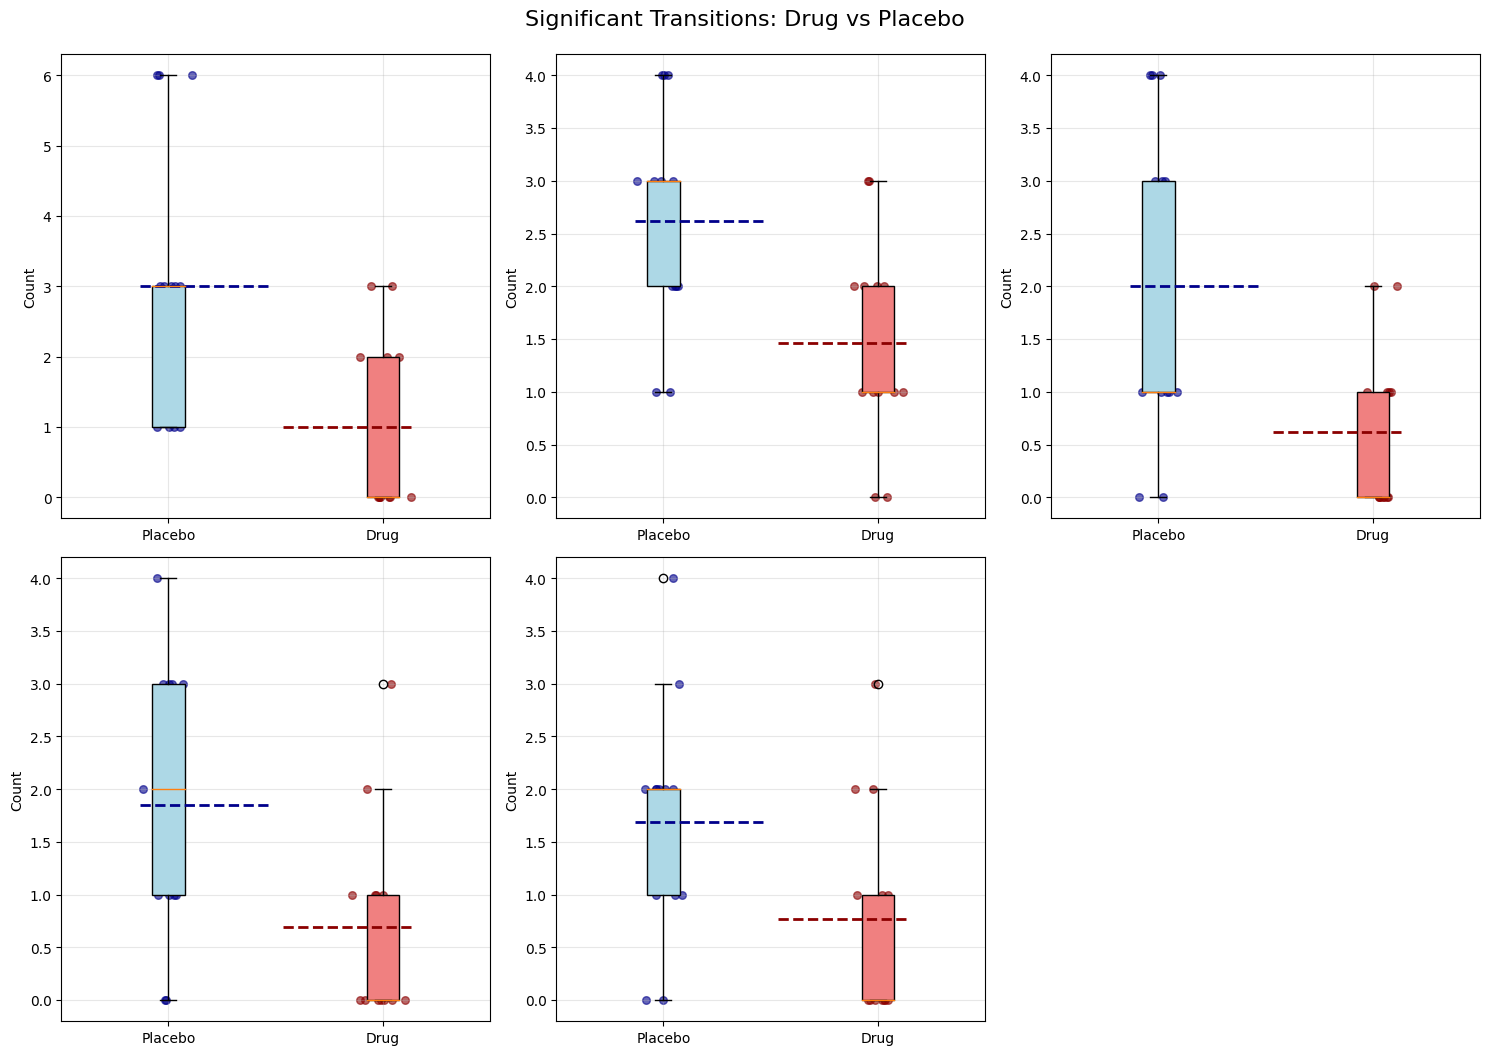

In [ ]:

trans_cols = [col for col in transition_df.columns if ' to ' in col]

placebo_df = transition_df[transition_df['State'] == 'Placebo']
drug_df = transition_df[transition_df['State'] == 'Drug']

test_results = []

# Run Mann-Whitney U test for each transition
for transition in trans_cols:
    placebo_data = placebo_df[transition]
    drug_data = drug_df[transition]
    
    if placebo_data.sum() < 5 or drug_data.sum() < 5:
        continue
    
    # Run the test
    try:
        u_stat, p_value = mannwhitneyu(placebo_data, drug_data, alternative='two-sided')
        
        # Store results
        test_results.append({
            'Transition': transition,
            'U_Statistic': u_stat,
            'P_Value': p_value,
            'Placebo_Mean': placebo_data.mean(),
            'Drug_Mean': drug_data.mean(),
            'Mean_Difference': drug_data.mean() - placebo_data.mean(),
            'Placebo_Median': placebo_data.median(),
            'Drug_Median': drug_data.median(),
            'Significant': p_value < 0.05
        })
    except:
        continue

results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values(by='P_Value').reset_index(drop=True)
print("Mann-Whitney U Test Results for All Transitions:")
print(results_df[['Transition', 'P_Value', 'Significant']].to_string(index=False))
significant_transitions = results_df[results_df['Significant']]['Transition'].tolist()
print(f"\nNumber of significant transitions: {len(significant_transitions)}")

def plot_significant_transitions(significant_transitions, placebo_df, drug_df, results_df):
    if not significant_transitions:
        print("No significant transitions found to plot.")
        return
    
    n_plots = len(significant_transitions)
    grid_size = int(np.ceil(np.sqrt(n_plots)))
    rows = grid_size
    cols = grid_size
    
    fig = plt.figure(figsize=(15, 15))
    gs = GridSpec(rows, cols, figure=fig)
    
    for i, transition in enumerate(significant_transitions):
        if i >= rows * cols:
            break  
            
        placebo_data = placebo_df[transition]
        drug_data = drug_df[transition]
        
        row_data = results_df[results_df['Transition'] == transition].iloc[0]
        p_value = row_data['P_Value']
        
        row_idx = i // cols
        col_idx = i % cols
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        bp = ax.boxplot([placebo_data, drug_data], labels=['Placebo', 'Drug'], patch_artist=True)
        
        colors = ['lightblue', 'lightcoral']
        for box, color in zip(bp['boxes'], colors):
            box.set(facecolor=color)
        
        for j, (data, pos) in enumerate(zip([placebo_data, drug_data], [1, 2])):
            x_jitter = np.random.normal(0, 0.05, size=len(data))
            ax.scatter(np.full_like(data, pos) + x_jitter, data, alpha=0.6, 
                      c='darkblue' if j == 0 else 'darkred', s=30)
        
        ax.set_ylabel('Count')
        ax.grid(alpha=0.3)
        
        for j, (data, pos) in enumerate(zip([placebo_data, drug_data], [1, 2])):
            ax.axhline(y=data.mean(), xmin=pos/3 - 0.15, xmax=pos/3 + 0.15, 
                      color='darkblue' if j == 0 else 'darkred', linestyle='--', linewidth=2)
    
    plt.tight_layout()
    plt.suptitle("Significant Transitions: Drug vs Placebo", fontsize=16, y=1.02)
    plt.show()
    
plot_significant_transitions(significant_transitions, placebo_df, drug_df, results_df)

### State Transition Probability Matrices

For a sequence of centroids $X = [X_1, X_2, \ldots, X_T]$ where each $X_t \in \{0,1,\ldots,k\}$, the transition probability matrix $P$ provides the probability of transitioning from one centroid to another.



#### Transition Probability Matrix

The transition probability matrix $P$ is then calculated by normalizing each row of the count matrix:

$$
P_{ij} = \frac{C_{ij}}{\sum_{j=0}^k C_{ij}}
$$

This gives the probability of transitioning from centroid $i$ to centroid $j$, conditioned on the current state being $i$.



#### Transition Probability per Subject / State

In [27]:
probability_matrices = {}
subjects = transition_df['Subject'].unique()
states = transition_df['State'].unique()

# For each subject and state
for subject in subjects:

    if subject not in probability_matrices:
        probability_matrices[subject] = {}
        
    for state in states:
        df_subset = transition_df[(transition_df['Subject'] == subject) & 
                                 (transition_df['State'] == state)]
        
        if df_subset.empty:
            continue
            
        transition_matrix = np.zeros((k+1, k+1))
        
        for i in range(k+1):
            for j in range(k+1):
                if i != j:  
                    transition_key = f"{i+1} to {j+1}"
                    if transition_key in df_subset.columns:
                        transition_matrix[i, j] = df_subset[transition_key].values[0]

        row_sums = transition_matrix.sum(axis=1)
        
       
        probability_matrix = np.zeros_like(transition_matrix, dtype=float)
        for i in range(k+1):
            if row_sums[i] > 0: 
                for j in range(k+1):
                    if i != j:
                        probability_matrix[i, j] = transition_matrix[i, j] / row_sums[i]
        
        # Dict
        probability_matrices[subject][state] = probability_matrix

#### Invariant Measure

For a Markov chain with transition probability matrix P, the invariant measure (also called stationary distribution) is a probability vector $\pi$ that satisfies:

$\pi$ × P = $\pi$

where:
- $\pi$ is a row vector representing the invariant measure
- P is the transition probability matrix
- The entries of $\pi$ sum to 1

The invariant measure $\pi$ gives the limiting probability of being in each state after many transitions, regardless of the starting state. In other words, $\pi_i$ is the proportion of time the system spends in state $i$ in the long run.

**Calculation Method:**
- **Power Iteration**: Repeatedly multiply any initial probability distribution by $P$ until convergence:
   $\pi = lim_{k→∞} v × P^k$
   where $v$ is any initial probability distribution.

In [45]:
# Invariant measure - Power Iteration method

invariant_measures = {}

for subject in probability_matrices:
    invariant_measures[subject] = {}
    
    for state in probability_matrices[subject]:

        P = probability_matrices[subject][state]
        n = len(P)
        
        P_adjusted = P.copy()
        row_sums = P_adjusted.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]
        
        # For states with no outgoing transitions, distribute probability evenly
        for i in zero_rows:
            for j in range(n):
                if i != j:  # Keep diagonal as 0
                    P_adjusted[i, j] = 1 / (n - 1)
        
        # Recalculate row sums after adjustment
        row_sums = P_adjusted.sum(axis=1)
        
        # Normalize rows to create a proper stochastic matrix
        for i in range(n):
            if row_sums[i] > 0:
                P_adjusted[i] = P_adjusted[i] / row_sums[i]
        
        
        # Power iteration
        pi = np.ones(n) / n
        max_iter = 1000
        epsilon = 1e-10
        
        for _ in range(max_iter):
            pi_new = pi @ P_adjusted
            
            # Check for convergence
            if np.max(np.abs(pi_new - pi)) < epsilon:
                break
                
            pi = pi_new
        
        # Normalize to ensure it sums to 1 (may not be necessary if P is row-stochastic)
        pi = pi / pi.sum()
        
        # Store the invariant measure
        invariant_measures[subject][state] = pi

print(f"Ex. Subject {1}:")
print("\nPlacebo invariant measure:")
print(invariant_measures[1]['Placebo'])
print("\nDrug invariant measure:")
print(invariant_measures[1]['Drug'])


Ex. Subject 1:

Placebo invariant measure:
[0.1240435  0.1449859  0.33507853 0.28755538 0.10833669]

Drug invariant measure:
[0.32352941 0.11764706 0.23529412 0.11764706 0.20588235]


#### Markov Chain Entropy

The entropy of a Markov chain measures the uncertainty or randomness in the state transitions. It quantifies how predictable the system's behavior is over time.

For a Markov chain with transition probability matrix $P$ and invariant measure (stationary distribution) $\pi$, the entropy is given by:

$$H = -\sum_{i} \pi_i \sum_{j} p_{ij} \log_2(p_{ij})$$

Where:
- $\pi_i$ is the invariant measure for state $i$ (long-term probability of being in state $i$)
- $p_{ij}$ is the transition probability from state $i$ to state $j$

- **Higher entropy** indicates more uncertainty or randomness in transitions
- **Lower entropy** indicates more predictable transition patterns

Comparing entropy between different conditions (Placebo vs. Drug) can reveal whether a treatment affects the predictability of state transitions in the underlying system.

In [50]:
# Dictionary to store entropy values
entropy_values = {}

for subject in probability_matrices:
    entropy_values[subject] = {}
    
    for state in probability_matrices[subject]:

        P = probability_matrices[subject][state]
        pi = invariant_measures[subject][state]
        
        # Initialize entropy
        entropy = 0.0
        
        # Calculate entropy
        for i in range(len(P)):

            if pi[i] < 1e-10:
                continue
            state_entropy = 0.0
            for j in range(len(P)):
                if P[i, j] > 1e-10:
                    state_entropy -= P[i, j] * np.log2(P[i, j])
            
            # Weight
            entropy += pi[i] * state_entropy
        
        # Store
        entropy_values[subject][state] = entropy


entropy_df = []
for subject in entropy_values:
    for state in entropy_values[subject]:
        entropy_df.append({
            'Subject': subject,
            'State': state,
            'Entropy': entropy_values[subject][state]
        })
entropy_df = pd.DataFrame(entropy_df)

entropy_df.head(20)

,Subject,State,Entropy
0,1,Drug,1.409729
1,1,Placebo,1.288939
2,2,Drug,1.612055
3,2,Placebo,1.568691
4,3,Drug,1.341151
5,3,Placebo,1.410434
6,4,Drug,1.207477
7,4,Placebo,1.446816
8,5,Drug,1.074328
9,5,Placebo,1.610793



Summary Statistics for Entropy:

Normality Test (Shapiro-Wilk):
Placebo: W=0.9690, p-value=0.8818
Drug: W=0.9433, p-value=0.5014

Paired t-test for difference in entropy between Placebo and Drug:
t-statistic: 0.7952
p-value: 0.4419
Conclusion: No significant difference at α = 0.05


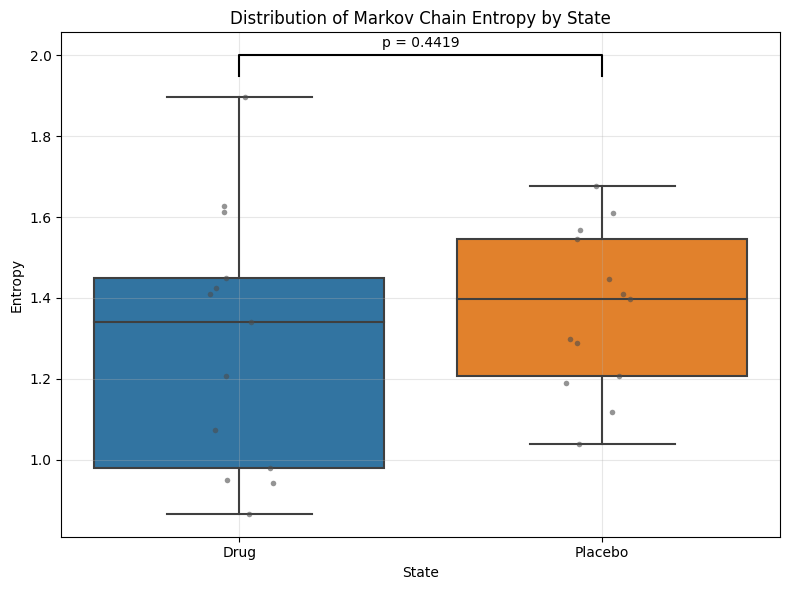

In [55]:
# Statistical comparison of entropy between Placebo and Drug states
print("\nSummary Statistics for Entropy:")

# Extract entropy values for each state
placebo_entropy = entropy_df[entropy_df['State'] == 'Placebo']['Entropy']
drug_entropy = entropy_df[entropy_df['State'] == 'Drug']['Entropy']

# Shapiro-Wilk test for normality
print("\nNormality Test (Shapiro-Wilk):")
print(f"Placebo: W={stats.shapiro(placebo_entropy)[0]:.4f}, p-value={stats.shapiro(placebo_entropy)[1]:.4f}")
print(f"Drug: W={stats.shapiro(drug_entropy)[0]:.4f}, p-value={stats.shapiro(drug_entropy)[1]:.4f}")

#Statistical test for difference in distributions
# If data is normally distributed, use paired t-test, If not use Wilcoxon

alpha = 0.05
paired_data = pd.merge(
            entropy_df[entropy_df['State'] == 'Placebo'][['Subject', 'Entropy']],
            entropy_df[entropy_df['State'] == 'Drug'][['Subject', 'Entropy']],
            on='Subject', suffixes=('_Placebo', '_Drug')
        )
        
if (stats.shapiro(placebo_entropy)[1] > alpha) and (stats.shapiro(drug_entropy)[1] > alpha):
    t_stat, p_val = stats.ttest_rel(paired_data['Entropy_Placebo'], paired_data['Entropy_Drug'])
    test_name = "Paired t-test"
else:
    # Wilcoxon signed-rank test for paired non-parametric data
    w_stat, p_val = stats.wilcoxon(paired_data['Entropy_Placebo'], paired_data['Entropy_Drug'])
    test_name = "Wilcoxon signed-rank test"
        
# Print results
print(f"\n{test_name} for difference in entropy between Placebo and Drug:")
if 't_stat' in locals():
    print(f"t-statistic: {t_stat:.4f}")
elif 'w_stat' in locals():
    print(f"W-statistic: {w_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Conclusion: {'Significant difference' if p_val < alpha else 'No significant difference'} at α = {alpha}")

# boxplot with statistical annotation
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='State', y='Entropy', data=entropy_df)
sns.stripplot(x='State', y='Entropy', data=entropy_df, size=4, color='.3', alpha=0.6)

y_max = entropy_df['Entropy'].max()
y_min = entropy_df['Entropy'].min()
y_range = y_max - y_min
y_pos = y_max + 0.05 * y_range

plt.plot([0, 0, 1, 1], [y_pos, y_pos + 0.05 * y_range, y_pos + 0.05 * y_range, y_pos], color='k')
plt.text(0.5, y_pos + 0.07 * y_range, f"p = {p_val:.4f}", ha='center')

plt.title('Distribution of Markov Chain Entropy by State')
plt.ylabel('Entropy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Initialize
rows = []
k = max(Centroids)
start_idx = 0

# Combine both state indices and state names
all_indices = [(plc_idx[-1],'Placebo')]+[(drug_idx[-1],'Drug')]

# Calculate the prob for all subjects and states (Placebo and Drug)
for i, (end_idx, state) in enumerate(all_indices):

    
    #Exctract the centroids per subject
    subject_centroids = Centroids[start_idx:end_idx]
    
    # Calculate probability 
    unique_centroids, counts = np.unique(subject_centroids, return_counts=True)
    centroid_counts = dict(zip(unique_centroids, counts))
    total_observations = len(subject_centroids)
    
    
    avg_consecutive = {}
    median_consecutive = {}
   
    for centroid in range(k + 1):

        # Calculate average consecutive length - median for each centroid
        runs = []
        current_run = 0
        
        for c in subject_centroids:
            if c == centroid:
                current_run += 1
            elif current_run > 0:
                runs.append(current_run)
                current_run = 0
                
    
        if current_run > 0:
            runs.append(current_run)
            
        # Calculate average - median
        if runs:
            avg_consecutive[centroid] = sum(runs) / len(runs)
            median_consecutive[centroid] = np.median(runs)
        else:
            avg_consecutive[centroid] = 0
            median_consecutive[centroid] = 0


        frequency = centroid_counts.get(centroid, 0)
        probability = frequency / total_observations
        avg_consec = avg_consecutive.get(centroid, 0)
        median_consec = median_consecutive.get(centroid,0)

        rows.append({
            'State': state,
            'Centroid': centroid,
            'Frequency': frequency,
            'Probability': probability,
            'Avg_Consecutive': avg_consec,
            'Median_Consecutive': median_consec
        })
    
    start_idx = end_idx

# Dataframe
result_df = pd.DataFrame(rows)
result_df['Probability'] = result_df['Probability'].round(4)
result_df['Avg_Consecutive'] = result_df['Avg_Consecutive'].round(2)
result_df['Centroid'] = result_df['Centroid'] + 1
result_df = result_df.sort_values(by=['State', 'Centroid']).reset_index(drop=True)
result_df.head(10)

,State,Centroid,Frequency,Probability,Avg_Consecutive,Median_Consecutive
0,Drug,1,202,0.1602,3.37,3.0
1,Drug,2,286,0.2268,3.25,2.0
2,Drug,3,412,0.3267,3.89,2.0
3,Drug,4,104,0.0825,2.31,2.0
4,Drug,5,257,0.2038,3.13,2.0
5,Placebo,1,268,0.2188,3.48,3.0
6,Placebo,2,130,0.1061,2.06,2.0
7,Placebo,3,432,0.3527,3.35,2.0
8,Placebo,4,255,0.2082,3.19,2.0
9,Placebo,5,140,0.1143,2.46,2.0



#### Difference Matrix

$$
D_{ij} = P^{\text{drug}}_{ij} - P^{\text{placebo}}_{ij}
$$

Positive values in $D_{ij}$ indicate transitions that become more likely under the drug condition, while negative values indicate transitions that become less likely.

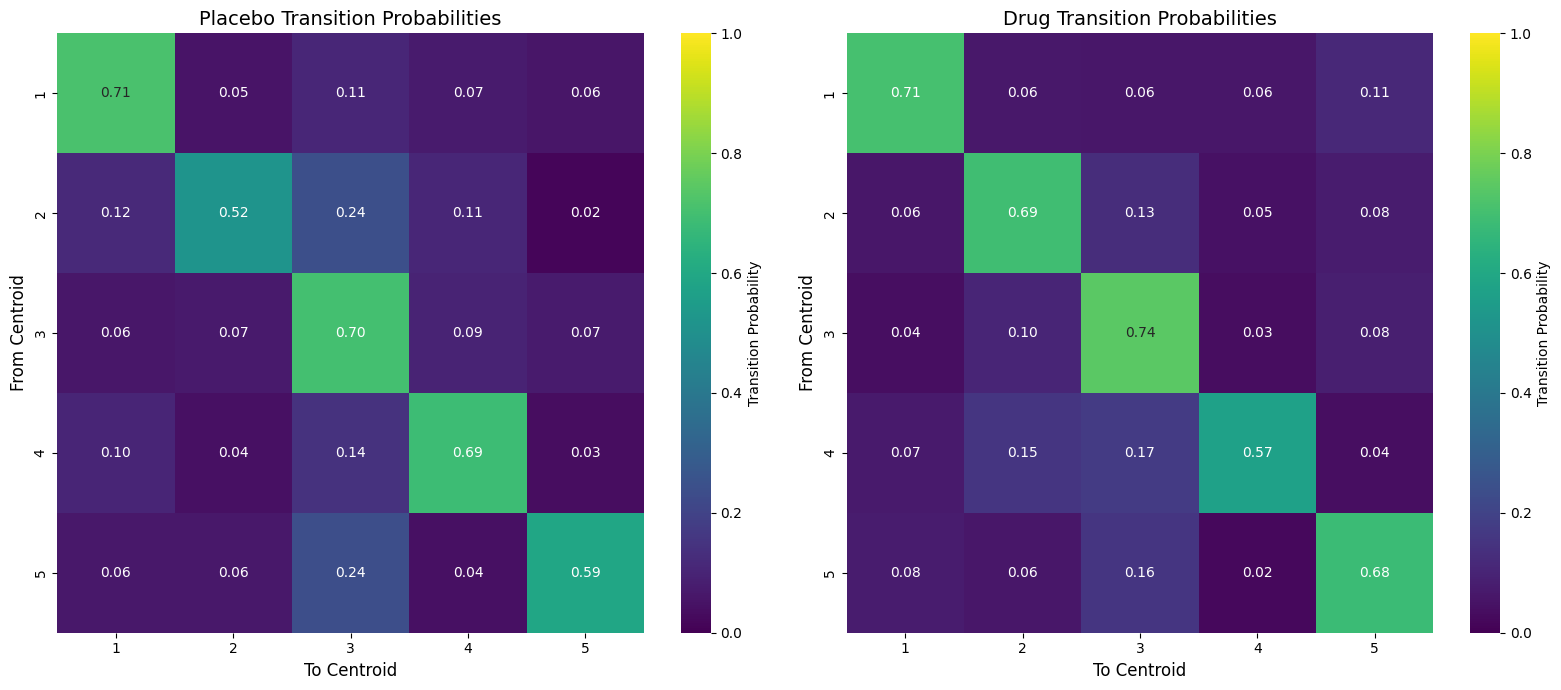

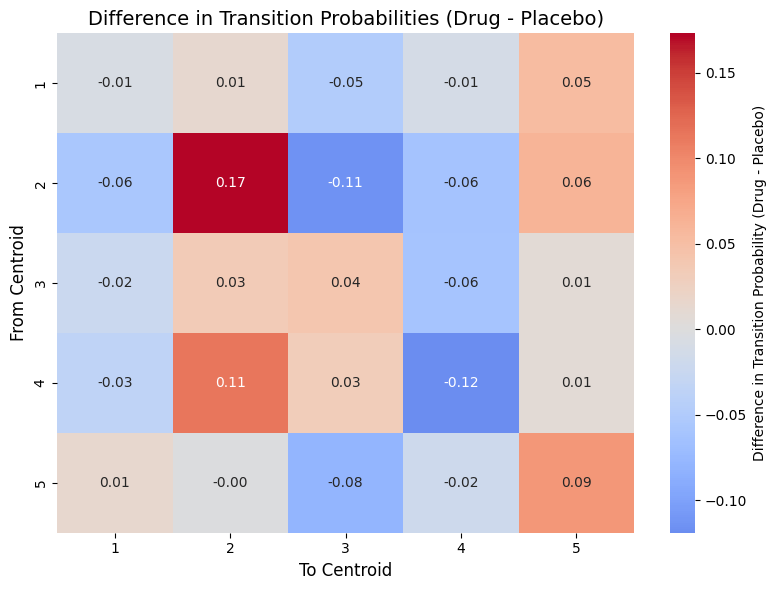

In [ ]:
### Transition Probabilities (With Repetition)

# Initialize transition matrices
k = max(Centroids)  # Number of centroids
placebo_transitions = np.zeros((k+1, k+1))
drug_transitions = np.zeros((k+1, k+1))

# Process placebo data
start_idx = 0
end_idx = plc_idx[-1]
placebo_centroids = Centroids[start_idx:end_idx]

# Count transitions for placebo
for i in range(len(placebo_centroids) - 1):
    from_state = placebo_centroids[i]
    to_state = placebo_centroids[i + 1]
    placebo_transitions[from_state, to_state] += 1

# Process drug data
start_idx = plc_idx[-1]
end_idx = drug_idx[-1]
drug_centroids = Centroids[start_idx:end_idx]

# Count transitions for drug
for i in range(len(drug_centroids) - 1):
    from_state = drug_centroids[i]
    to_state = drug_centroids[i + 1]
    drug_transitions[from_state, to_state] += 1

# Normalize Rows (Probabilities) 

placebo_row_sums = placebo_transitions.sum(axis=1, keepdims=True)
placebo_row_sums[placebo_row_sums == 0] = 1  
placebo_transition_probs = placebo_transitions / placebo_row_sums

drug_row_sums = drug_transitions.sum(axis=1, keepdims=True)
drug_row_sums[drug_row_sums == 0] = 1 
drug_transition_probs = drug_transitions / drug_row_sums

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot placebo transition matrix
sns.heatmap(
    placebo_transition_probs,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    ax=axes[0],
    cbar=True,
    cbar_kws={'label': 'Transition Probability'}
)
axes[0].set_title('Placebo Transition Probabilities', fontsize=14)
axes[0].set_xlabel('To Centroid', fontsize=12)
axes[0].set_ylabel('From Centroid', fontsize=12)
centroid_labels = [str(i+1) for i in range(k+1)]
axes[0].set_xticklabels(centroid_labels)
axes[0].set_yticklabels(centroid_labels)

# Plot drug transition matrix
sns.heatmap(
    drug_transition_probs,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    ax=axes[1],
    cbar=True,
    cbar_kws={'label': 'Transition Probability'}
)
axes[1].set_title('Drug Transition Probabilities', fontsize=14)
axes[1].set_xlabel('To Centroid', fontsize=12)
axes[1].set_ylabel('From Centroid', fontsize=12)
axes[1].set_xticklabels(centroid_labels)
axes[1].set_yticklabels(centroid_labels)

plt.tight_layout()
plt.show()

# Difference matrix (Drug - Placebo)

fig_diff, ax_diff = plt.subplots(figsize=(8, 6))
diff_matrix = drug_transition_probs - placebo_transition_probs

sns.heatmap(
    diff_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax_diff,
    cbar_kws={'label': 'Difference in Transition Probability (Drug - Placebo)'}
)
ax_diff.set_title('Difference in Transition Probabilities (Drug - Placebo)', fontsize=14)
ax_diff.set_xlabel('To Centroid', fontsize=12)
ax_diff.set_ylabel('From Centroid', fontsize=12)
ax_diff.set_xticklabels(centroid_labels)
ax_diff.set_yticklabels(centroid_labels)

plt.tight_layout()
plt.show()

### Transition Probabilities (Without Repetition)

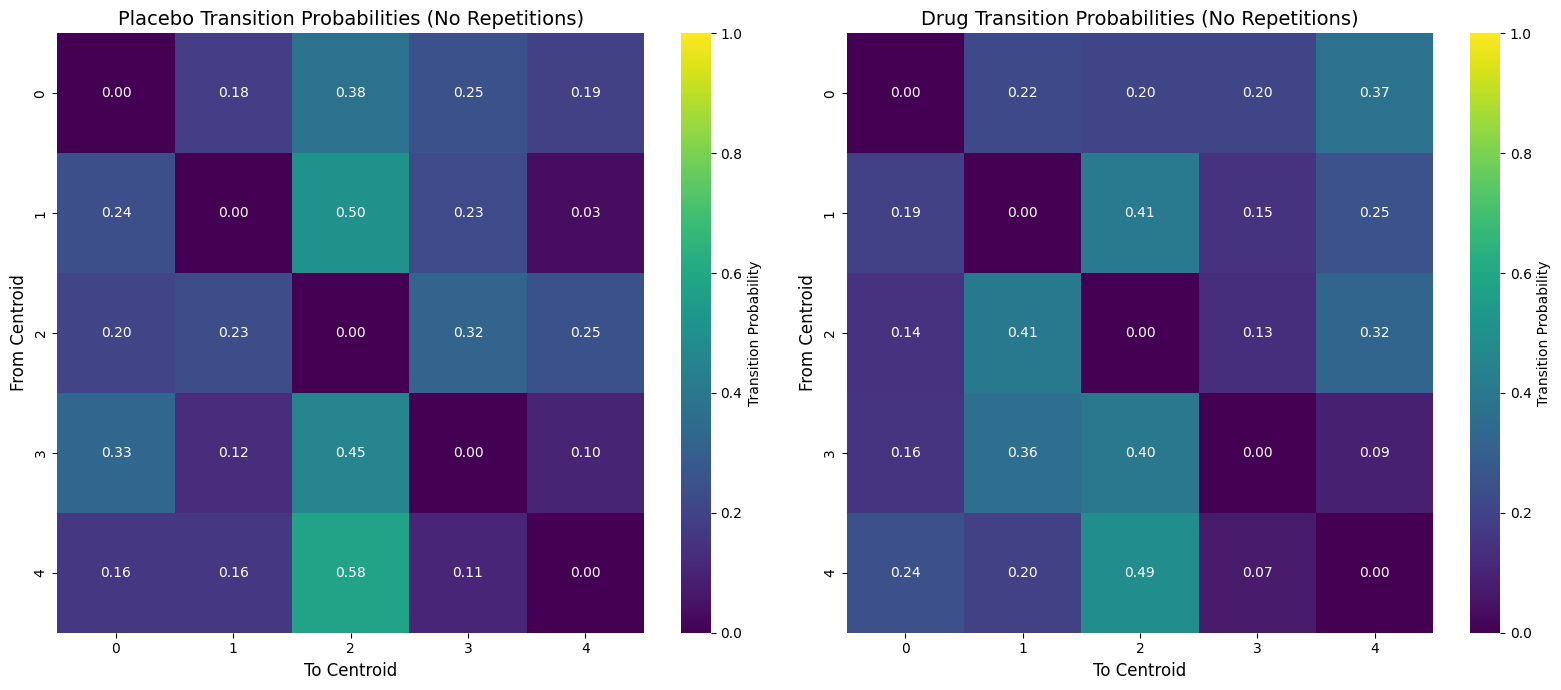

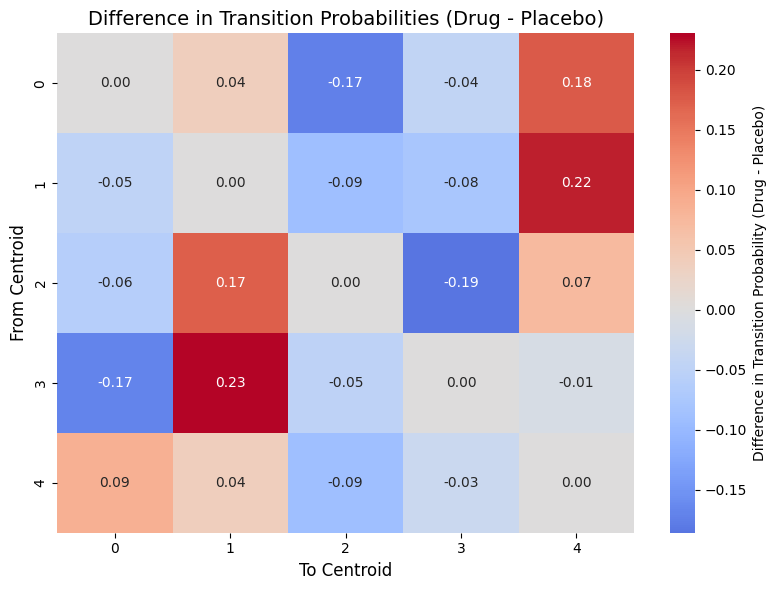

In [ ]:
# Initialize transition matrices
k = max(Centroids)  # Number of centroids
placebo_transitions = np.zeros((k+1, k+1))
drug_transitions = np.zeros((k+1, k+1))

# Function to remove consecutive duplicates
def remove_consecutive_duplicates(arr):
    if len(arr) == 0:
        return arr
    result = [arr[0]]
    for i in range(1, len(arr)):
        if arr[i] != arr[i-1]:
            result.append(arr[i])
    return result

# Process placebo data
start_idx = 0
end_idx = plc_idx[-1]
placebo_centroids = Centroids[start_idx:end_idx]
# Remove consecutive duplicates
placebo_centroids_no_rep = remove_consecutive_duplicates(placebo_centroids)

# Count transitions for placebo
for i in range(len(placebo_centroids_no_rep) - 1):
    from_state = placebo_centroids_no_rep[i]
    to_state = placebo_centroids_no_rep[i + 1]
    placebo_transitions[from_state, to_state] += 1

# Process drug data
start_idx = plc_idx[-1]
end_idx = drug_idx[-1]
drug_centroids = Centroids[start_idx:end_idx]
# Remove consecutive duplicates
drug_centroids_no_rep = remove_consecutive_duplicates(drug_centroids)

# Count transitions for drug
for i in range(len(drug_centroids_no_rep) - 1):
    from_state = drug_centroids_no_rep[i]
    to_state = drug_centroids_no_rep[i + 1]
    drug_transitions[from_state, to_state] += 1

# Normalize Rows (Probabilities)
placebo_row_sums = placebo_transitions.sum(axis=1, keepdims=True)
placebo_row_sums[placebo_row_sums == 0] = 1  
placebo_transition_probs = placebo_transitions / placebo_row_sums

drug_row_sums = drug_transitions.sum(axis=1, keepdims=True)
drug_row_sums[drug_row_sums == 0] = 1 
drug_transition_probs = drug_transitions / drug_row_sums

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot placebo transition matrix
sns.heatmap(
    placebo_transition_probs,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    ax=axes[0],
    cbar=True,
    cbar_kws={'label': 'Transition Probability'}
)
axes[0].set_title('Placebo Transition Probabilities (No Repetitions)', fontsize=14)
axes[0].set_xlabel('To Centroid', fontsize=12)
axes[0].set_ylabel('From Centroid', fontsize=12)
centroid_labels = [str(i) for i in range(k+1)]
axes[0].set_xticklabels(centroid_labels)
axes[0].set_yticklabels(centroid_labels)

# Plot drug transition matrix
sns.heatmap(
    drug_transition_probs,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    ax=axes[1],
    cbar=True,
    cbar_kws={'label': 'Transition Probability'}
)
axes[1].set_title('Drug Transition Probabilities (No Repetitions)', fontsize=14)
axes[1].set_xlabel('To Centroid', fontsize=12)
axes[1].set_ylabel('From Centroid', fontsize=12)
axes[1].set_xticklabels(centroid_labels)
axes[1].set_yticklabels(centroid_labels)

plt.tight_layout()
plt.show()

# Difference matrix (Drug - Placebo)
fig_diff, ax_diff = plt.subplots(figsize=(8, 6))
diff_matrix = drug_transition_probs - placebo_transition_probs

sns.heatmap(
    diff_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax_diff,
    cbar_kws={'label': 'Difference in Transition Probability (Drug - Placebo)'}
)
ax_diff.set_title('Difference in Transition Probabilities (Drug - Placebo)', fontsize=14)
ax_diff.set_xlabel('To Centroid', fontsize=12)
ax_diff.set_ylabel('From Centroid', fontsize=12)
ax_diff.set_xticklabels(centroid_labels)
ax_diff.set_yticklabels(centroid_labels)

plt.tight_layout()
plt.show()

### Visualization

In [ ]:
# Clustering States
n_state = 5
cidx = Kmeans_results[n_state]['cidx_Pha'] 
L = cidx.shape[0]
T_shift = 9


id_aal = np.arange(1, 91) 
id_deco = np.concatenate([np.linspace(1, 89, 45, dtype=int), np.linspace(2, 90, 45, dtype=int)[::-1]])
deco_to_aal_mapping = np.searchsorted(id_aal, id_deco)  
CC2 = CC[np.ix_(deco_to_aal_mapping, deco_to_aal_mapping)] 
VC = CC.flatten().astype(np.float64)



# Compute correlations between centroids and connectome
CCA = np.zeros(n_state)
for i in range(n_state):
    centroid_vector = Kmeans_results[n_state]['ctrs_Pha'][i, :]
    QQ = squareform(centroid_vector) 
    VA = QQ.flatten()
    MC = np.corrcoef(VA, VC)  # Correlation with the connectome
    CCA[i] = MC[0, 1]

B = np.sort(CCA)
I = np.argsort(CCA)


rate = np.zeros(n_state)
ratea = np.zeros(n_state)
rateb = np.zeros(n_state)

denom = L - 2 * T_shift 
mid = len(cidx) // 2  #We concatenated 2 time series (drug + placebo)


for bst in range(n_state):
    rate[bst]  = np.sum(cidx == I[bst]) / denom
    ratea[bst] = np.sum(cidx[:mid] == I[bst]) / denom
    rateb[bst] = np.sum(cidx[mid:] == I[bst]) / denom


# Compute cumulative time spent per subject
times_matrix_k = np.zeros((num, 2))
times_matrix_p = np.zeros((num, 2))

for idx, i in enumerate(num_patients):
    size_value_k = data_PSILO[i]['TS_Psilo'].shape[1]
    size_value_p = data_PSILO[i]['TS_PCB'].shape[1]

    times_matrix_k[idx, 0] = size_value_k
    times_matrix_p[idx, 0] = size_value_p

    times_matrix_k[idx, 1] = size_value_k if idx == 0 else times_matrix_k[idx-1, 1] + size_value_k
    times_matrix_p[idx, 1] = size_value_p if idx == 0 else times_matrix_p[idx-1, 1] + size_value_p

scratekt = np.zeros((num, n_state))
scratektp = np.zeros((num, n_state))

for s in range(num):
    for j in range(n_state):
        if s == 0:
            scratekt[s, j] = np.sum(cidx[:int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226:1226 + int(times_matrix_p[s, 1])] == I[j]) / times_matrix_p[s, 1]
        else:
            scratekt[s, j] = np.sum(cidx[int(times_matrix_k[s-1, 1]):int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226 + int(times_matrix_p[s-1, 1]): 1226 + int(times_matrix_p[s, 1]) - 20] == I[j]) / times_matrix_p[s, 1]


CH = np.zeros((num * 2, n_state))

for i in range(n_state):
    CH[:, i] = np.concatenate([scratekt[:, i], scratektp[:, i]])

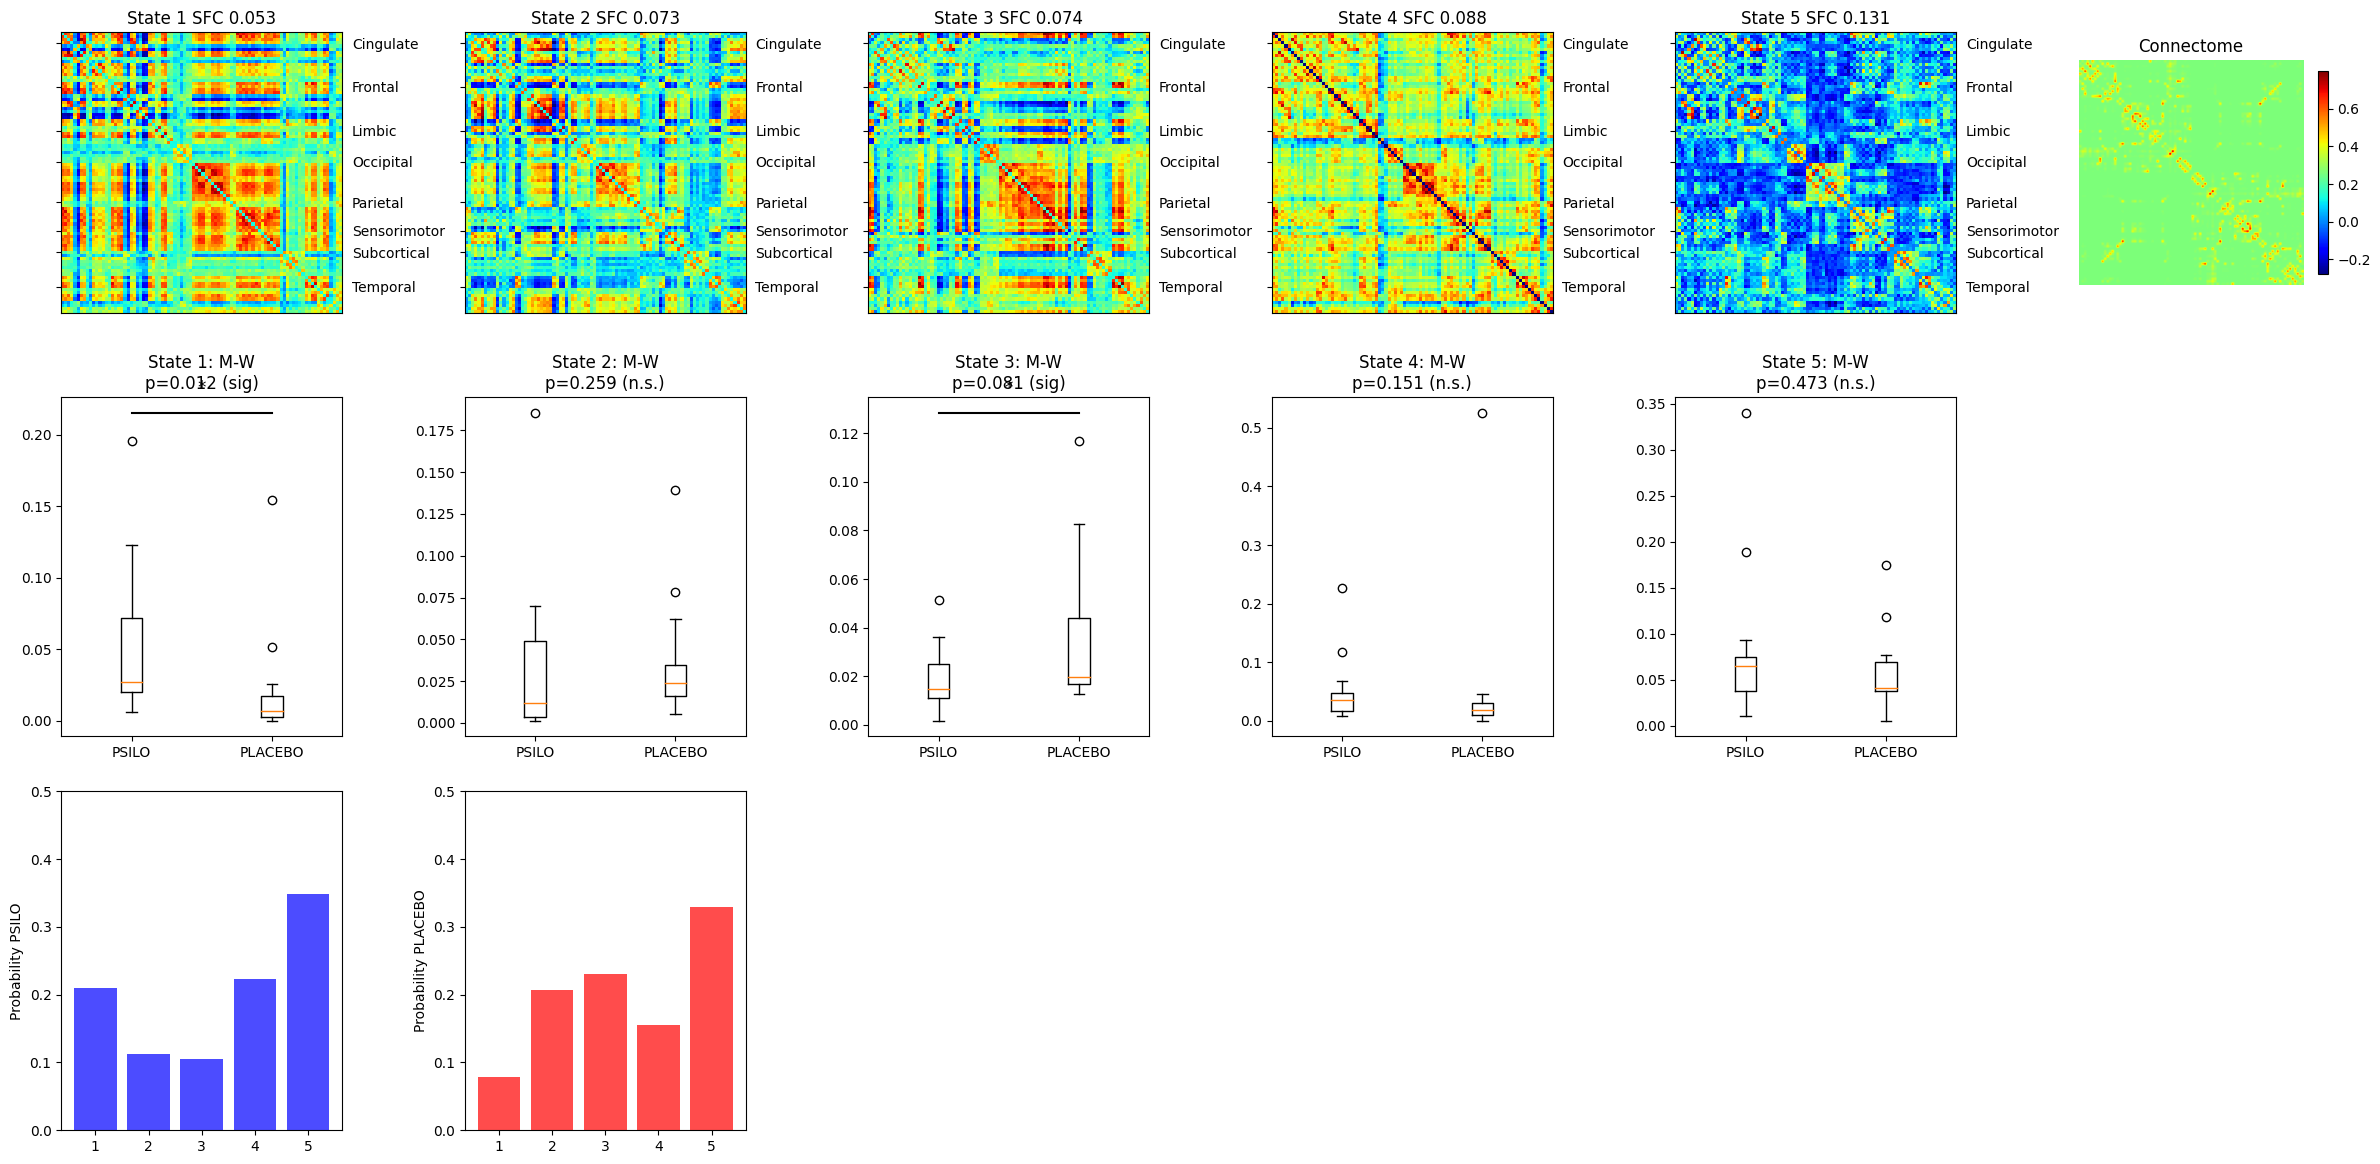

In [ ]:
fig, axs = plt.subplots(3, n_state + 1, figsize=(4*(n_state+1), 12))

#Correlation matrices of each state

#Normalizar por plot (Su rango)**
for i in range(n_state):
    QQ = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])

    labels = reorder_matrix(QQ)[2] 
    unique_labels, indices = np.unique(labels, return_index=True)
    centers = [(indices[j] + (indices[j+1] if j+1 < len(indices) else len(labels))) / 2 for j in range(len(indices))]
    im = axs[0, i].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
    axs[0, i].set_title(f"State {i+1} SFC {B[i]:.3f}")
    axs[0,i].set_yticks(centers)
    axs[0,i].set_yticklabels(unique_labels)
    axs[0,i].tick_params(axis="y", labelright=True, labelleft=False)
    axs[0,i].set_xticks([]) 
    axs[0,i].tick_params(axis="x", which="both", bottom=False, top=False)  

#Connectome matrix
axs[0, n_state].imshow(CC, vmin=-1, vmax=1, cmap='jet')
axs[0, n_state].set_title("Connectome")
axs[0, n_state].axis("off")
plt.colorbar(im, ax=axs[0, n_state], shrink=0.6)

#Boxplots for each state with statistical test
alpha = 0.1

for i in range(n_state):
    # Extract data for the two groups
    psilo_data = CH[:num, i]
    placebo_data = CH[num:, i]
    
    # Perform Shapiro-Wilk test to check for normality
    _, p_psilo = stats.shapiro(psilo_data)
    _, p_placebo = stats.shapiro(placebo_data)
    
    # Determine which test to use based on normality
    if p_psilo > 0.05 and p_placebo > 0.05:
        # Both distributions are normal, use t-test
        _, p_value = stats.ttest_ind(psilo_data, placebo_data, equal_var=False)
        test_name = "t-test"
    else:
    # At least one distribution is not normal, use Mann-Whitney U test
         _, p_value = stats.mannwhitneyu(psilo_data, placebo_data)
         test_name = "M-W"
    
    # Create boxplot
    axs[1, i].boxplot([psilo_data, placebo_data], labels=["PSILO", "PLACEBO"])
    
    # Add statistical test result to the plot
    significance = "sig" if p_value < alpha else "n.s."
    axs[1, i].set_title(f"State {i+1}: {test_name}\np={p_value:.3f} ({significance})")
    
    # Add horizontal line to show significance
    if p_value < alpha:
        y_max = max(np.max(psilo_data), np.max(placebo_data))
        y_pos = y_max * 1.1
        axs[1, i].plot([1, 2], [y_pos, y_pos], 'k-')
        axs[1, i].text(1.5, y_pos * 1.05, '*', ha='center', va='bottom', fontsize=12)

axs[1, n_state].axis('off')

#Bar plots for state probabilities in MDMA and PLACEBO
axs[2, 0].bar(np.arange(1, n_state+1), ratea/np.sum(ratea), color='blue', alpha=0.7)
axs[2, 0].set_ylim([0, 0.5])
axs[2, 0].set_ylabel('Probability PSILO')

axs[2, 1].bar(np.arange(1, n_state+1), rateb/np.sum(rateb), color='red', alpha=0.7)
axs[2, 1].set_ylim([0, 0.5])
axs[2, 1].set_ylabel('Probability PLACEBO')

# Hide remaining columns
for j in range(2, n_state+1):
    axs[2, j].axis('off')

plt.tight_layout()
plt.show()

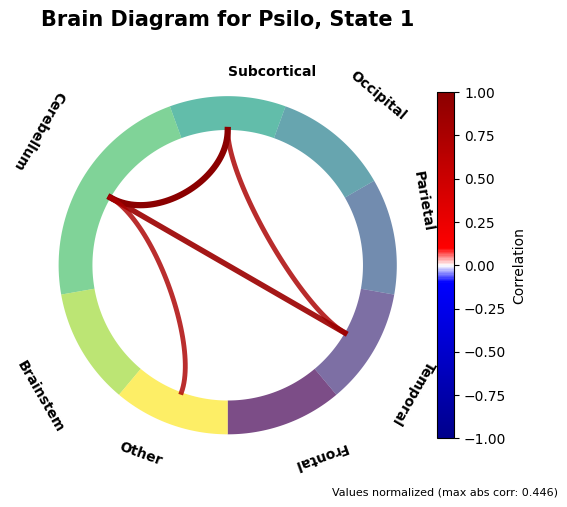

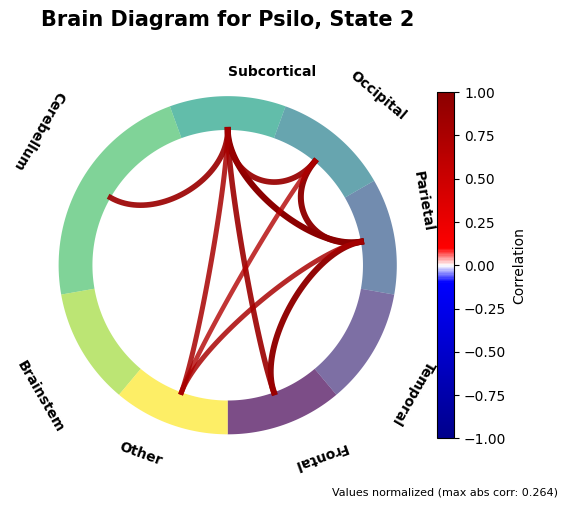

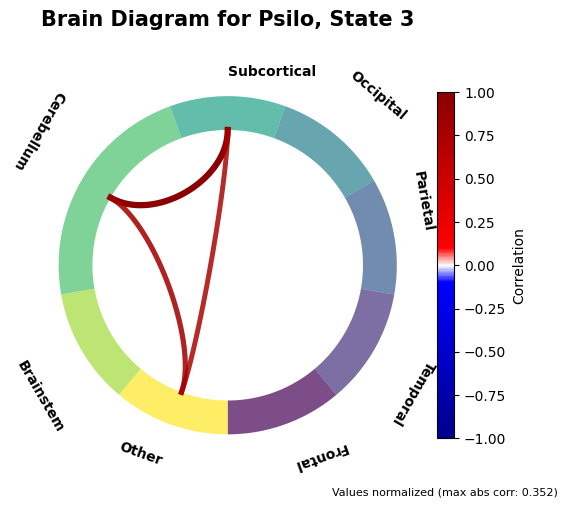

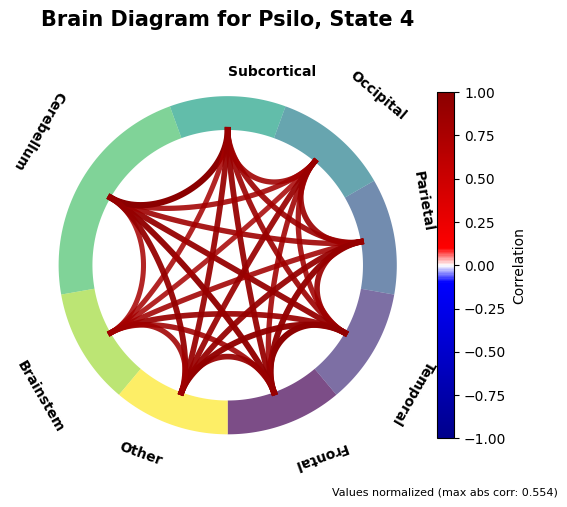

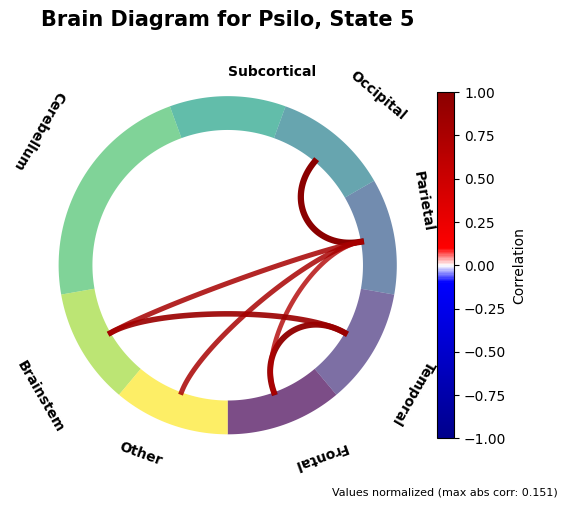

In [ ]:
#Example of Usage (Chord Diagram with Correlation Matrix State)

# Calculate and visualize correlation matrices for each state
for i in range(n_state):
    state_matrix = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])

    fig = chord_diagram(
    state_matrix,
    region_boundaries=[10,20,30,40,50,70,80,90],
    region_names = ["Frontal", "Temporal", "Parietal", "Occipital", "Subcortical", "Cerebellum", "Brainstem", "Other"],       
    threshold=0.7,
    mean=True,
    name=f"Brain Diagram for Psilo, State {i+1}")
    plt.show()


C:\Users\diego\AppData\Local\Temp\ipykernel_16332\2920853338.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
C:\Users\diego\AppData\Local\Temp\ipykernel_16332\2920853338.py:20: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')


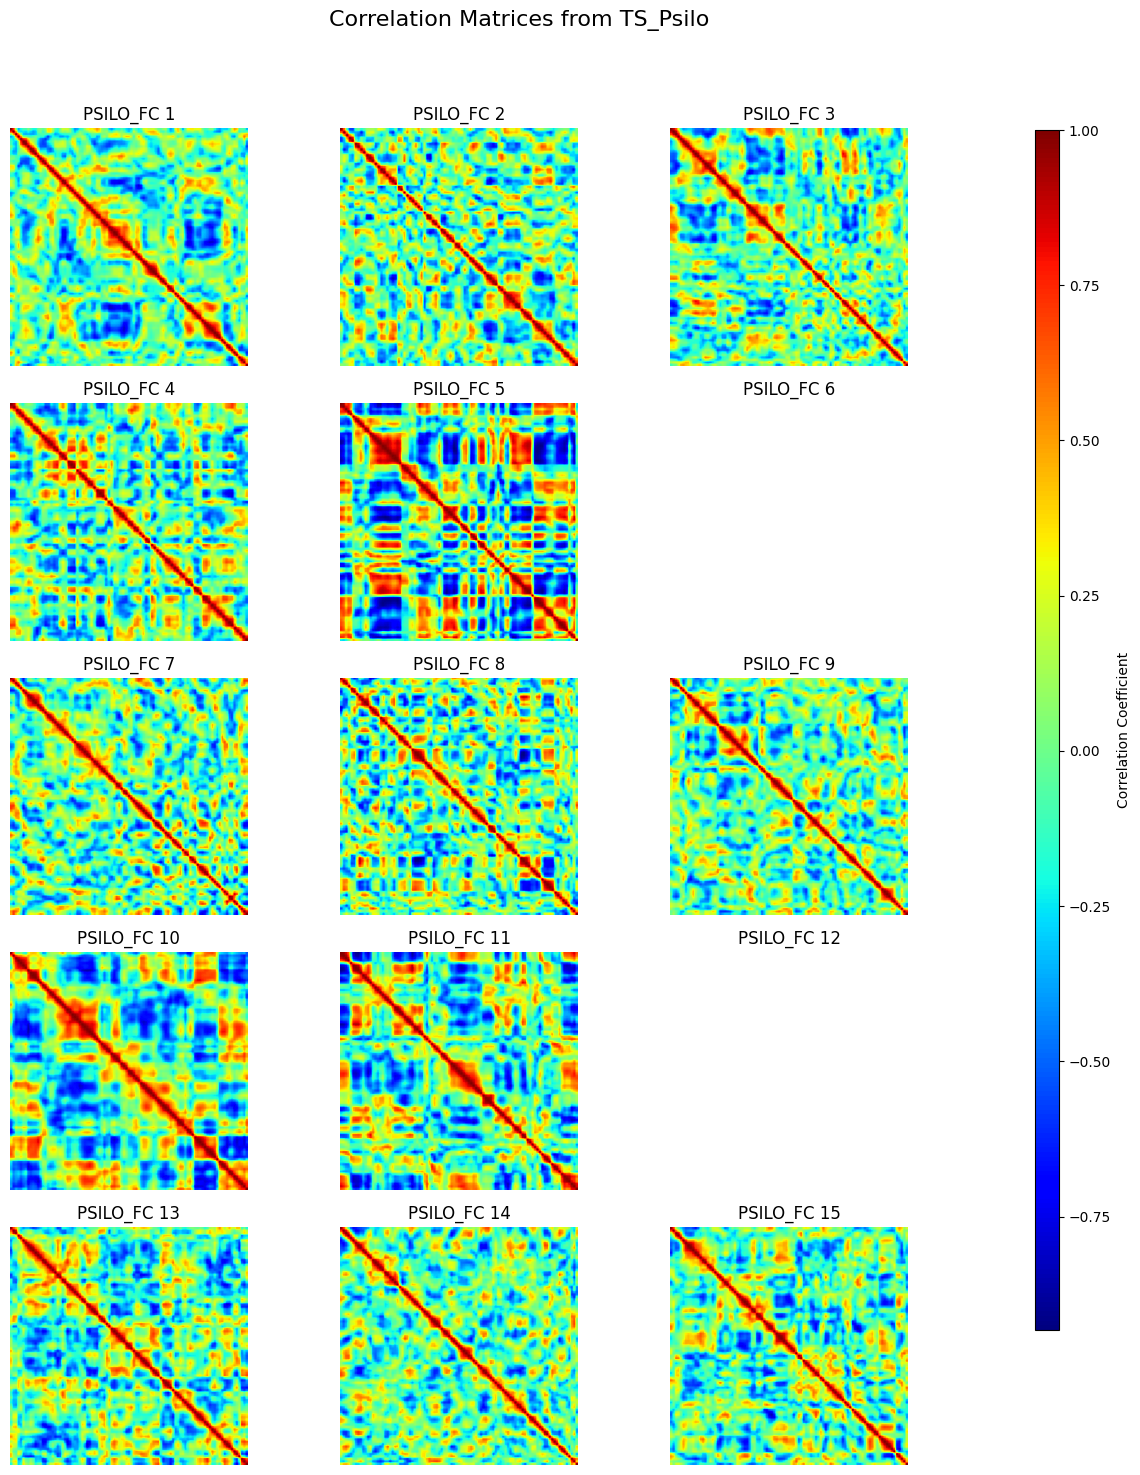

In [ ]:
# We plot all the correlation matrix even there's corrupted data
num_patients=data_PSILO["TS_Psilo"].shape[0]


fig, axs = plt.subplots(int(np.ceil(num_patients / 3)), 3, figsize=(12, 15))

#Time Series Psilo
corr_mats = [np.corrcoef(data_PSILO['TS_Psilo'][k].T) for k in range(num_patients)]
all_corr_values = np.concatenate([corr_mat.flatten() for corr_mat in corr_mats])
min_val, max_val = np.min(all_corr_values), np.max(all_corr_values)


#Plots
for k, corr_mat in enumerate(corr_mats):
    row = k // 3  
    col = k % 3
    ax = axs[row, col]
    
    # Mostrar la matriz de correlación
    im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
    ax.axis("off")
    ax.set_title(f"PSILO_FC {range(num_patients)[k]+1}") 

for k in range(num, int(np.ceil(num / 3) * 3)):
    row = k // 3
    col = k % 3
    axs[row, col].axis('off')


fig.suptitle('Correlation Matrices from TS_Psilo', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax, label='Correlation Coefficient')
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_16332\3002459001.py:20: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
C:\Users\diego\AppData\Local\Temp\ipykernel_16332\3002459001.py:20: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')


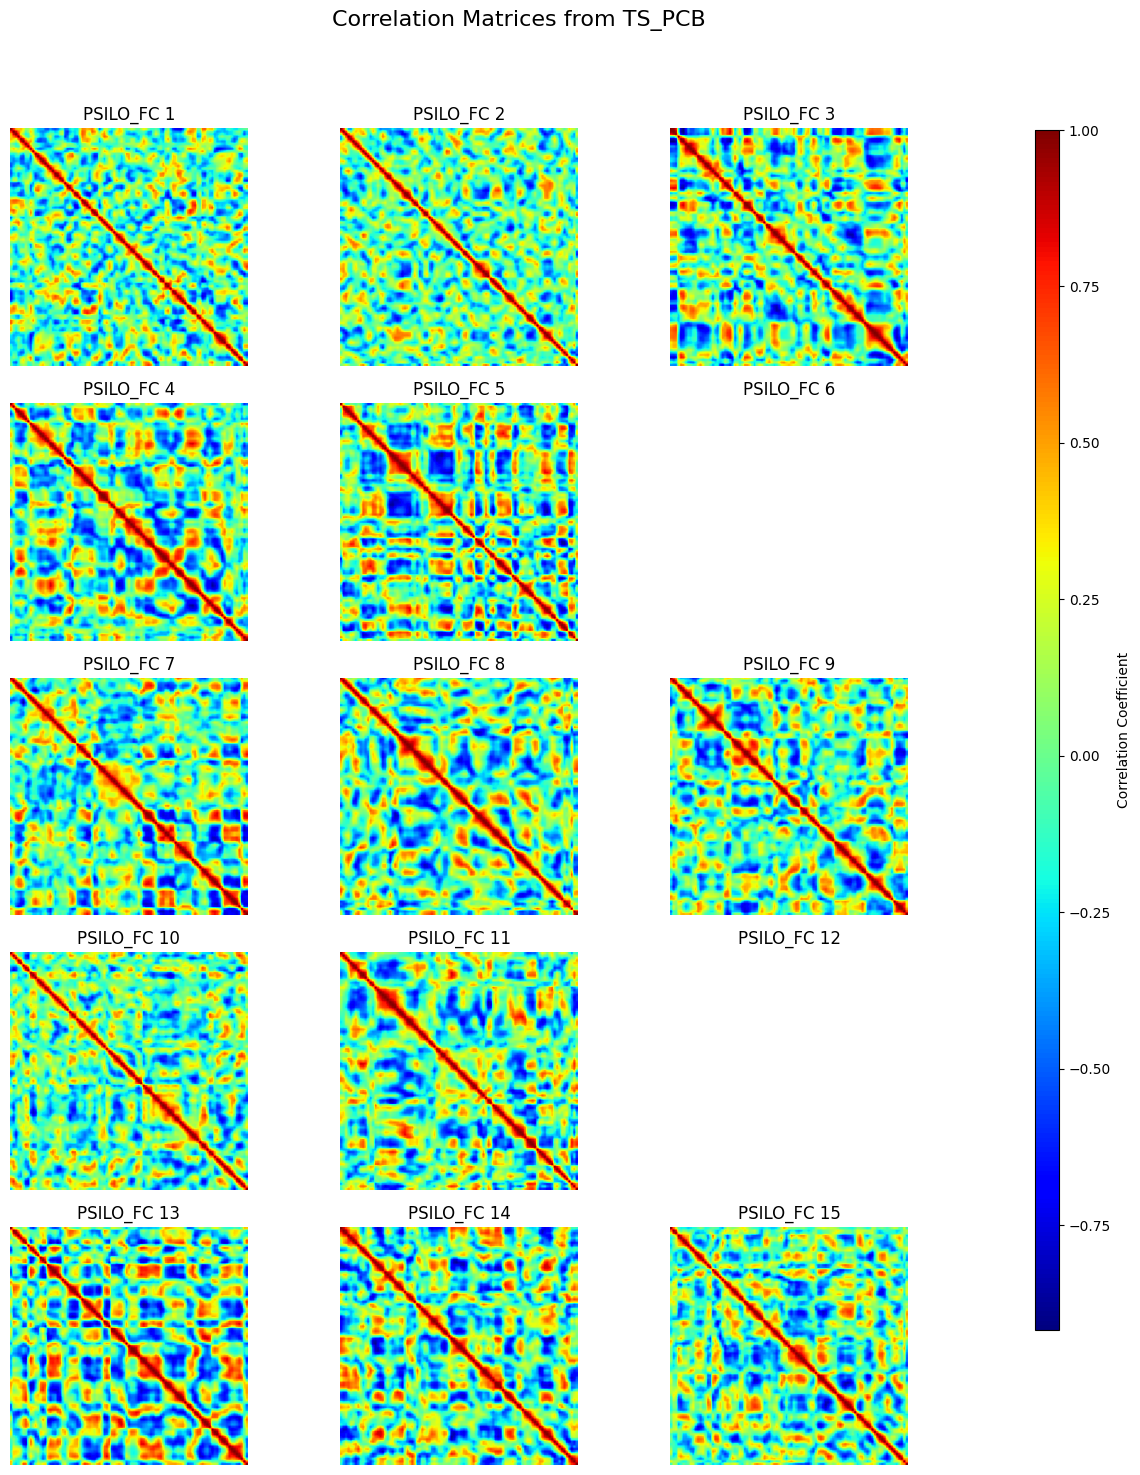

In [ ]:
# We plot all the correlation matrix even there's corrupted data
num_patients=data_PSILO["TS_PCB"].shape[0]


fig, axs = plt.subplots(int(np.ceil(num_patients / 3)), 3, figsize=(12, 15))

#Time Series Psilo
corr_mats = [np.corrcoef(data_PSILO['TS_PCB'][k].T) for k in range(num_patients)]
all_corr_values = np.concatenate([corr_mat.flatten() for corr_mat in corr_mats])
min_val, max_val = np.min(all_corr_values), np.max(all_corr_values)


#Plots
for k, corr_mat in enumerate(corr_mats):
    row = k // 3  
    col = k % 3
    ax = axs[row, col]
    
    # Mostrar la matriz de correlación
    im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
    ax.axis("off")
    ax.set_title(f"PSILO_FC {range(num_patients)[k]+1}") 

for k in range(num, int(np.ceil(num / 3) * 3)):
    row = k // 3
    col = k % 3
    axs[row, col].axis('off')


fig.suptitle('Correlation Matrices from TS_PCB', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax, label='Correlation Coefficient')
plt.show()